In [ ]:
import snapatac2 as snap    
import nbformat as nbf
import umap
import scvi
import numpy as np
import scanpy as sc
import anndata as ad
import pandas as pd

/home/elliot/miniconda3/envs/atac_env190516/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
data = snap.pp.import_fragments(
    "/mnt/claw-raid/elliot/P002_mtscATAC-seq/data/raw/241121-cortex_results_masked/fragments.tsv.gz",
    chrom_sizes=snap.genome.hg38,  #
    sorted_by_barcode=False,
)
data          

AnnData object with n_obs × n_vars = 65340 × 0
    obs: 'n_fragment', 'frac_dup', 'frac_mito'
    uns: 'reference_sequences'
    obsm: 'fragment_paired'

In [5]:
## Bit of extra information:
'''
1. Nucleosome-Free Region (NFR): The majority of fragments are short, typically around 80-300 base pairs (bp) in length. 
These short fragments represent regions of open chromatin where DNA is relatively accessible and not bound to nucleosomes. 
These regions are often referred to as nucleosome-free regions (NFRs) and correspond to regions of active transcriptional 
regulation.

2. Mono-Nucleosome Peaks: There is often a peak in the fragment size distribution at around 147-200 bp, 
which corresponds to the size of a single nucleosome wrapped DNA. These fragments result from the 
cutting of DNA by the transposase enzyme when it encounters a nucleosome, 
causing the DNA to be protected and resulting in fragments of the same size.

3. Di-Nucleosome Peaks: In addition to the mono-nucleosome peak, you may also observe 
a smaller peak at approximately 300-400 bp, corresponding to di-nucleosome fragments. 
These fragments occur when transposase cuts the DNA between two neighboring nucleosomes.

4. Large Fragments: Some larger fragments, greater than 500 bp in size, may be observed. 
These fragments can result from various sources, such as the presence of 
longer stretches of open chromatin or technical artifacts.
'''

#Idk why this isn't wokring something to do with chrome wtf

snap.pl.frag_size_distr(data, interactive=False)

ValueError: 
Image export using the "kaleido" engine requires the Kaleido package,
which can be installed using pip:

    $ pip install --upgrade kaleido


In [3]:
## Same plot with axis to log scale
fig = snap.pl.frag_size_distr(data, show=False)
fig.update_yaxes(type="log")
fig.show()

2026-03-30 18:18:41 - INFO - Computing fragment size distribution...


/home/elliot/miniconda3/envs/atac_env/lib/python3.9/site-packages/kaleido/_sync_server.py:11: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.




In [6]:
## TSS enrichment implies there is an increased accessibility or fragmentation of chromatin around the TSS
## Often indicative of promoter regions
snap.metrics.tsse(data, snap.genome.hg38)

In [7]:
## To identify usable/high-quality cells, we can plot TSSe scores against number of unique fragments for each cell.
snap.pl.tsse(data, interactive=True)
data
##The cells in the upper right represent valid or high-quality cells, whereas those in the lower left represent low-quality 
# cells or empty droplets. Based on this plot, 
#we decided to set a minimum TSS enrichment of 10 and a minimum number of fragments of 5,000 to filter the cells.

AnnData object with n_obs × n_vars = 65340 × 0
    obs: 'n_fragment', 'frac_dup', 'frac_mito', 'tsse'
    uns: 'reference_sequences', 'library_tsse', 'frac_overlap_TSS', 'TSS_profile'
    obsm: 'fragment_paired'

In [8]:
## OprionL - Filtering cells here results in fewer mitochondrial variants deteced
snap.pp.filter_cells(data, min_counts=1000, min_tsse=10, max_counts=100000)
data

AnnData object with n_obs × n_vars = 1228 × 0
    obs: 'n_fragment', 'frac_dup', 'frac_mito', 'tsse'
    uns: 'reference_sequences', 'library_tsse', 'frac_overlap_TSS', 'TSS_profile'
    obsm: 'fragment_paired'

In [9]:
## Cell by bin matrix containng insertion counts across 500bp bins across the genome
snap.pp.add_tile_matrix(data)

In [10]:
## Feature selection, which will be stored in data.var['selected'] this is particularly relevant for scrublet and spectral
## Selects most accessible features 
## n_features determines number of features, experiment with n_features to find the optimal number for your dataset
snap.pp.select_features(data, n_features=250000)

2026-05-30 18:44:35 - INFO - Selected 250000 features.


In [11]:

## Scrublet is used to remove potential dublets. It will assign probabilities to each cell, and then we can filter
snap.pp.scrublet(data)
#snap.pp.scrublet(data)
snap.pp.filter_doublets(data)
data

2026-05-30 18:44:35 - INFO - Simulating doublets...
2026-05-30 18:44:35 - INFO - Spectral embedding ...
2026-05-30 18:45:01 - INFO - Calculating doublet scores...
2026-05-30 18:45:02 - INFO - Detected doublet rate = 1.303%


AnnData object with n_obs × n_vars = 1212 × 6062095
    obs: 'n_fragment', 'frac_dup', 'frac_mito', 'tsse', 'doublet_probability', 'doublet_score'
    var: 'count', 'selected'
    uns: 'reference_sequences', 'library_tsse', 'frac_overlap_TSS', 'TSS_profile', 'scrublet_sim_doublet_score', 'doublet_rate'
    obsm: 'fragment_paired'

In [12]:
## Spectral embedding is used for dimensionality reduction
## Stored in data.obsm['X_spectral']
snap.tl.spectral(data)
snap.tl.umap(data)

/home/elliot/miniconda3/envs/atac_env190516/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [13]:
## Perform graph based clustering, build k-nearest neighbour graph then use leiden algorithm to identify clusters
snap.pp.knn(data)
snap.tl.leiden(data, resolution=0.7)  # Adjust resolution for more or fewer clusters

In [14]:
snap.pl.umap(data, color='leiden', interactive=True, height=500)

In [25]:
#Get peaks using MACS3, which will be stored in data.uns['macs3']
snap.tl.macs3(data, groupby='leiden')
#Create a unified, non-overlapping, and fixed-width peak list 
peaks = snap.tl.merge_peaks(data.uns['macs3'], snap.genome.hg38)
peaks.head()
#Creating a peak matrix
peak_mat = snap.pp.make_peak_matrix(data, use_rep=peaks['Peaks'])
peak_mat
peak_mat.write_h5ad("/mnt/claw-raid/elliot/P002_mtscATAC-seq/data/processed/atac_PM_Ctx/atac_PM_Ctx_peakmatrix.h5ad")

2026-05-22 14:44:51 - INFO - Exporting fragments...
2026-05-22 14:44:56 - INFO - Calling peaks...
100%|██████████| 6/6 [02:24<00:00, 24.12s/it]
/home/elliot/miniconda3/envs/atac_env190516/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
... storing 'leiden' as categorical
... storing 'cell_type' as categorical


In [27]:
peaks


Peaks,1,0,4,5,3,2
str,bool,bool,bool,bool,bool,bool
"""chr1:9852-10353""",false,true,false,false,true,false
"""chr1:180588-181089""",false,false,false,false,false,true
"""chr1:191594-192095""",false,false,false,false,true,false
"""chr1:267749-268250""",false,true,true,true,false,false
"""chr1:274172-274673""",false,true,false,false,false,false
…,…,…,…,…,…,…
"""chrY:11721762-11722263""",true,true,true,true,false,true
"""chrY:11747461-11747962""",false,false,false,false,false,true
"""chrY:26315018-26315519""",false,true,false,false,false,false


In [29]:
#Regression-based differeintail test, accounts for variation across cells
#First, select peaks present in two cell types
group1 = "4"
group2 = "2"
InflamMcg = data.obs['leiden'] == group1
HomeoMcg = data.obs['leiden'] == group2
peaks_selected = np.logical_or(
    peaks[group1].to_numpy(),
    peaks[group2].to_numpy(),
)
#Then, perform differential test
diff_peaks = snap.tl.diff_test(
    peak_mat,
    cell_group1=InflamMcg,
    cell_group2=HomeoMcg,
    features=peaks_selected,
    min_log_fc = 0.1,  # Minimum log fold change to consider a peak as differentially accessible
    min_pct = 0.1,  # Minimum percentage of cells in either group that must have accessibility for the peak
)


2026-05-22 14:48:58 - INFO - Input contains 82117 features, now perform filtering with 'min_log_fc = 0.1' and 'min_pct = 0.1' ...
2026-05-22 14:49:14 - INFO - Testing 14728 features ...
100%|██████████| 14728/14728 [04:34<00:00, 53.73it/s]


In [10]:
#save differential peaks 
diff_peaks.write_csv("/mnt/claw-raid/elliot/P002_mtscATAC-seq/data/processed/atac_PM_Ctx/atac_PM_Ctx_diff_peaks.csv")

In [30]:
import polars as pl
#extract peak information into a dataframe "peaks"
peaks = diff_peaks.with_columns(
    pl.col("feature name").str.extract(r"^(chr[^:]+):(\d+)-(\d+)$", 1).alias("chrom"),
    pl.col("feature name").str.extract(r"^(chr[^:]+):(\d+)-(\d+)$", 2).cast(pl.Int64).alias("start"),
    pl.col("feature name").str.extract(r"^(chr[^:]+):(\d+)-(\d+)$", 3).cast(pl.Int64).alias("end"),
).select([
    pl.col("feature name").alias("peak_id"),
    "chrom", "start", "end",
    pl.col("log2(fold_change)").alias("log2FC"),
    pl.col("p-value").alias("pval"),
    pl.col("adjusted p-value").alias("padj"),
])

In [31]:
#extract annotation data from genome into dataframe "genes"
import pandas as pd

anno = snap.genome.hg38.annotation

ann_df = pd.read_csv(
    anno,
    sep="\t",
    comment="#",
    header=None,
    names=["chrom","source","type","start","end","score","strand","phase","attr"]
)

genes = ann_df[ann_df["type"] == "gene"].copy()
genes["gene_name"] = genes["attr"].str.extract(r"gene_name=([^;]+)")
genes = genes[["chrom", "start", "end", "gene_name"]]
genes

,chrom,start,end,gene_name
0,chr1,11869,14409,DDX11L1
12,chr1,14404,29570,WASH7P
25,chr1,17369,17436,MIR6859-1
28,chr1,29554,31109,MIR1302-2HG
36,chr1,30366,30503,MIR1302-2
...,...,...,...,...
1966610,chrM,14149,14673,MT-ND6
1966615,chrM,14674,14742,MT-TE
1966618,chrM,14747,15887,MT-CYB
1966623,chrM,15888,15953,MT-TT


In [32]:
#checks whether each peak overlaps any gene --> assigns first ovelapping gene name, very rough no TSS stuff, no labelling of truly intergenic peaks, just a simple overlap
#Problem is , two peaks can be mapped to one gene leading to duplicates on the colano plot
peaks_df = peaks.to_pandas()
peaks_df["gene_name"] = None

for chrom in peaks_df["chrom"].unique():
    p = peaks_df["chrom"] == chrom
    g = genes["chrom"] == chrom
    if g.any():
        genes_chr = genes[g]
        for i in peaks_df.loc[p].index:
            hit = genes_chr[
                (genes_chr["start"] <= peaks_df.at[i, "end"]) &
                (genes_chr["end"] >= peaks_df.at[i, "start"])
            ]
            if len(hit):
                peaks_df.at[i, "gene_name"] = hit["gene_name"].iloc[0]

In [33]:
#map back to differential peaks dataframe
diff_peaks = diff_peaks.join(pl.from_pandas(peaks_df[["peak_id", "gene_name"]]).rename({"peak_id": "feature name"}), on="feature name", how="left")

In [36]:
import polars as pl
import numpy as np

# thresholds
fc_thresh_log2 = np.log2(1.5)   # |log2FC| > 1.5
p_thresh       = 0.05

fc_col   = "log2(fold_change)"
p_col    = "adjusted p-value"
gene_col = "gene_name"

# significant peaks with |log2FC| > 1.5
sig = diff_peaks.filter(
    (pl.col(p_col) < p_thresh) &
    (pl.col(fc_col).abs() > fc_thresh_log2)
)

# top 100 upregulated genes (as a list)
top_up_100 = (
    sig
    .filter(pl.col(fc_col) > 0)
    .sort(fc_col, descending=True)
    .select(gene_col)
    .head(200)[gene_col]
    .to_list()
)

# top 100 downregulated genes (as a list)
top_down_100 = (
    sig
    .filter(pl.col(fc_col) < 0)
    .sort(fc_col, descending=False)
    .select(gene_col)
    .head(200)[gene_col]
    .to_list()
)

print("\nTop 100 upregulated genes:")
print(top_up_100)

print("\nTop 100 downregulated genes:")
print(top_down_100)

# --- write CSV of all sig DEGs for pasting ---
up_df = (
    sig
    .filter(pl.col(fc_col) > 0)
    .sort(fc_col, descending=True)
    .with_columns(pl.lit("upregulated_clusterA").alias("direction"))
    .with_row_index("rank", offset=1)
)

down_df = (
    sig
    .filter(pl.col(fc_col) < 0)
    .sort(fc_col, descending=False)
    .with_columns(pl.lit("upregulated_clusterB").alias("direction"))
    .with_row_index("rank", offset=1)
)

degs_csv = pl.concat([up_df, down_df])
degs_csv.write_csv("/mnt/claw-raid/elliot/P002_mtscATAC-seq/MitoDriftMaster/microgliaPM_degs.csv")
print(f"\nCSV written: {len(degs_csv)} significant DEGs ({len(up_df)} up in A, {len(down_df)} up in B)")


Top 100 upregulated genes:
[None, None, 'SGPL1', None, 'RPP38', 'LRMDA', 'SLC39A8', None, 'AHR', 'ENSG00000260926', 'RGCC', None, 'RAB27A', 'ENSG00000257526', 'IL1R2', 'PCBP1-AS1', 'VPS9D1', 'FNDC3B', None, 'RAB11FIP1', 'FAM126B', None, 'MEF2A', None, 'PPP1CB-DT', None, 'AFF1', 'EIF1B-AS1', None, 'PSMB4', 'CXCL3', 'EPN2', 'JAZF1', 'PPP1CB-DT', 'ENSG00000233096', 'ATG7', 'HEATR3', 'ENSG00000286113', 'RB1', 'IFNAR2', None, 'CXCL2', None, 'TAF1B', 'DYM', 'LINC00910', 'ANO5', 'MACF1', 'MBD3', 'PLA2G6', 'VDAC1', 'AREL1', 'ADIRF-AS1', 'HECW2', 'DPP8', 'TLR1', 'TM2D3', None, 'CRTC3', 'SRRM2-AS1', None, 'TPST1', 'ENSG00000287821', 'NFS1', 'CPNE8', 'BAHCC1', None, 'PARP10', 'ATP2A1-AS1', 'IER2', 'ETFA', None, None, 'ITGA4', 'H3-3B', 'ZNF559', 'ATAD3B', 'ENSG00000260729', 'PLEKHB2', 'C5AR1', None, 'ABCA1', 'TNFRSF1A', 'LINC01275', 'CCT5', 'SNRNP70', 'SBF2', 'NKIRAS1', 'TERF2', 'ENSG00000287958', 'LPIN1', 'ENSG00000284685', 'CISD2', 'GDPD1', 'RBPJ', 'GMEB2', 'ZFX', 'DMTF1-AS1', 'MAP4K3', 'EXOSC2

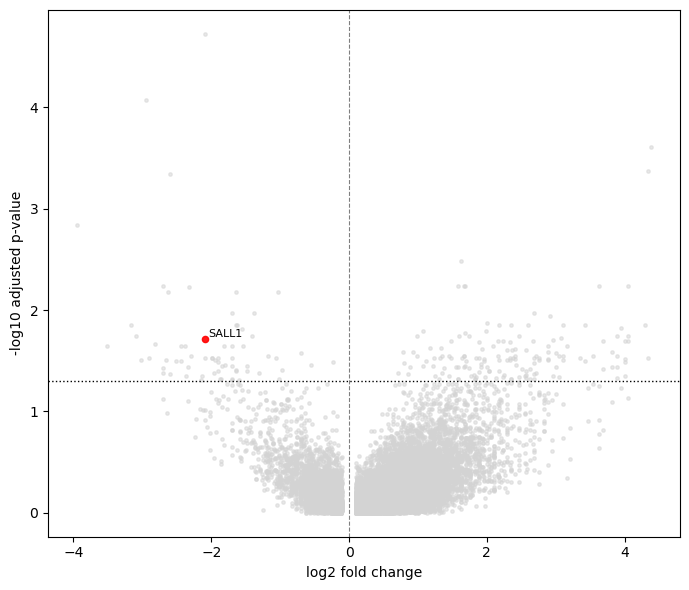

In [37]:
#this tries to get over the problem by picking the most significant peak, but is still bullshit 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from adjustText import adjust_text

genes_to_label = [
    "CXCL2", "CXCL3", "TNFRSF1A", "C5AR1", "IL1R2", "TLR1", "MAP3K14", "MEF2A", "ETFA", "ATAD3B", "VDAC1", "TM2D3", "LINC01275" ]


df = diff_peaks.to_pandas().copy()
df["gene_name"] = df["gene_name"].astype("string")
df["neglog10padj"] = -np.log10(df["adjusted p-value"].replace(0, np.nextafter(0, 1)))



lab = lab.loc[lab.groupby("gene_name")["adjusted p-value"].idxmin()].copy()

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(df["log2(fold_change)"], df["neglog10padj"], s=6, c="lightgrey", alpha=0.5)
ax.scatter(lab["log2(fold_change)"], lab["neglog10padj"], s=20, c="red", alpha=0.9)
ax.axhline(cutoff, color="black", linestyle=":", linewidth=1)
ax.axvline(0, color="black", linestyle="--", linewidth=0.8, alpha=0.5)

texts = []
for _, r in lab.iterrows():
    texts.append(
        ax.text(
            r["log2(fold_change)"],
            r["neglog10padj"],
            r["gene_name"],
            fontsize=8
        )
    )

adjust_text(
    texts,
    ax=ax,
    arrowprops=dict(arrowstyle="-", color="black", lw=0.5),
    expand_points=(1.2, 1.2),
    expand_text=(1.2, 1.2)
)

ax.set_xlabel("log2 fold change")
ax.set_ylabel("-log10 adjusted p-value")
plt.tight_layout()
plt.show()

Genes found for labeling:
['ATAD3B', 'C5AR1', 'CXCL2', 'CXCL3', 'ETFA', 'IL1R2', 'LINC01275', 'MAP3K14', 'MEF2A', 'TLR1', 'TM2D3', 'TNFRSF1A', 'VDAC1']
Genes missing from dataframe:
[]


2026-05-22 14:59:25 - WARNING - [5178 MB] Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


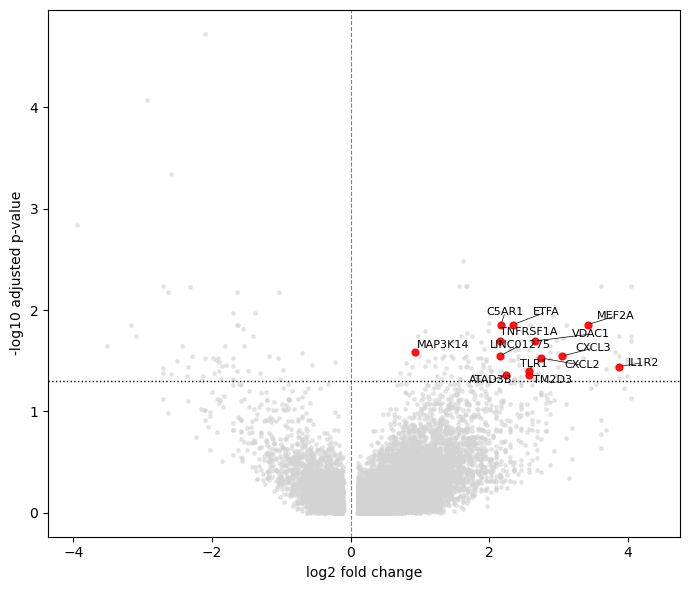

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from adjustText import adjust_text

genes_to_label = [
    "CXCL2", "CXCL3", "TNFRSF1A", "C5AR1", "IL1R2", "TLR1",
    "MAP3K14", "MEF2A", "ETFA", "ATAD3B", "VDAC1", "TM2D3", "LINC01275"
]

df = diff_peaks.to_pandas().copy()
df["gene_name"] = df["gene_name"].astype("string").str.strip()
df = df[df["gene_name"].notna()].copy()

df["adjusted p-value"] = pd.to_numeric(df["adjusted p-value"], errors="coerce")
df["log2(fold_change)"] = pd.to_numeric(df["log2(fold_change)"], errors="coerce")
df = df.dropna(subset=["gene_name", "adjusted p-value", "log2(fold_change)"]).copy()

df["neglog10padj"] = -np.log10(df["adjusted p-value"].replace(0, np.nextafter(0, 1)))

cutoff = -np.log10(0.05)

lab = df.loc[df.groupby("gene_name")["adjusted p-value"].idxmin()].copy()
lab = lab[lab["gene_name"].isin(genes_to_label)].copy()

print("Genes found for labeling:")
print(sorted(lab["gene_name"].unique().tolist()))

missing = sorted(set(genes_to_label) - set(lab["gene_name"].unique()))
print("Genes missing from dataframe:")
print(missing)

fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(
    df["log2(fold_change)"],
    df["neglog10padj"],
    s=6,
    c="lightgrey",
    alpha=0.5
)

ax.scatter(
    lab["log2(fold_change)"],
    lab["neglog10padj"],
    s=24,
    c="red",
    alpha=0.9
)

ax.axhline(cutoff, color="black", linestyle=":", linewidth=1)
ax.axvline(0, color="black", linestyle="--", linewidth=0.8, alpha=0.5)

texts = []
for _, r in lab.iterrows():
    texts.append(
        ax.text(
            r["log2(fold_change)"],
            r["neglog10padj"],
            r["gene_name"],
            fontsize=8
        )
    )

adjust_text(
    texts,
    ax=ax,
    arrowprops=dict(arrowstyle="-", color="black", lw=0.5),
    expand_points=(1.2, 1.2),
    expand_text=(1.2, 1.2)
)

ax.set_xlabel("log2 fold change")
ax.set_ylabel("-log10 adjusted p-value")
plt.tight_layout()
plt.show()

In [13]:
#ELLIOT - lucas' Clustering done annotation begins 
## Annotate the clusters and assign them to known cell types
## Compute gene activities for each cell using pp.make_gene_matrix

gene_matrix = snap.pp.make_gene_matrix(
    data, 
    gene_anno=snap.genome.hg38,
    gene_name_key='gene_id'  # Use Ensembl IDs instead of gene symbols
)

# Remove version numbers from Ensembl IDs
gene_matrix.var_names = gene_matrix.var_names.str.replace(r'\.\d+$', '', regex=True)



In [14]:
#ELLIOT - Lucas' annotation method 
#import RNA reference data

reference = sc.read_h5ad('/mnt/claw-raid/elliot/brainvasc_ref.h5ad')
reference = reference.raw.to_adata() #mkaes sure ref is raw data also not nomrlised
reference


# Check the cell type column name in your reference
print(reference.obs.columns)  # Find which column has cell types


Index(['author_cell_type', 'cell_type_ontology_term_id', 'donor_id',
       'development_stage_ontology_term_id', 'sex_ontology_term_id',
       'disease_ontology_term_id', 'is_primary_data', 'suspension_type',
       'tissue_ontology_term_id', 'tissue_type', 'assay_ontology_term_id',
       'self_reported_ethnicity_ontology_term_id', 'cell_type', 'assay',
       'disease', 'sex', 'tissue', 'self_reported_ethnicity',
       'development_stage', 'observation_joinid'],
      dtype='object')


In [15]:
#ELLIOT - Merge reference data and query data

# CRITICAL: Convert reference to use Ensembl IDs
reference.var_names = reference.var['ensembl_id'].values
reference.var_names_make_unique()

# Now merge
gene_matrix.obs['cell_type'] = 'Unknown'
integrated = ad.concat(  # ← Fixed typo: intergrated → integrated
    [reference, gene_matrix],
    join='inner',
    label='batch',
    keys=["reference", "query"],
    index_unique='_',
)

print(f"Combined shape: {integrated.shape}")

Combined shape: (66691, 30704)


In [16]:
# scanpy finds highly variable genes (batch correction)
#if you ask callum he will say this is shit because this is porabbly just to make it faster
sc.pp.filter_genes(integrated, min_cells=5)
#find hvg
sc.pp.highly_variable_genes(
    integrated,
    n_top_genes = 5000,
    flavor="seurat_v3",
    batch_key="batch",
    subset=True
)

In [17]:
#set up machine learning 
scvi.model.SCVI.setup_anndata(integrated, batch_key="batch")
vae = scvi.model.SCVI(
    integrated,
    n_layers=2,
    n_latent=30,
    gene_likelihood="nb",
    dispersion="gene-batch",
)

2025-11-22 15:52:09 - INFO - Unable to initialize backend 'cuda': 
2025-11-22 15:52:09 - INFO - Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
2025-11-22 15:52:09 - INFO - Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


In [18]:
#pretraining model?
vae.train(max_epochs=100, early_stopping=True, enable_progress_bar=True)
#if it's taking forever, maybe subset your ref dataset or uncrease that batch size


/home/elliot/miniconda3/envs/atac_env/lib/python3.9/site-packages/lightning/fabric/plugins/environments/slurm.py:204: PossibleUserWarning:

The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/elliot/miniconda3/envs/atac_env/lib/python3.9/ ...

INFO: GPU available: False, used: False
2025-11-22 15:52:17 - INFO - GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
2025-11-22 15:52:17 - INFO - TPU available: False, using: 0 TPU cores
/home/elliot/miniconda3/envs/atac_env/lib/python3.9/site-packages/lightning/fabric/plugins/environments/slurm.py:204: PossibleUserWarning:

The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/elliot/miniconda3/envs/atac_env/lib/python3.9/ ...

/home/elliot/miniconda3/en

Epoch 100/100: 100%|██████████| 100/100 [17:50<00:00, 10.61s/it, v_num=1, train_loss_step=971, train_loss_epoch=1e+3]     

INFO: `Trainer.fit` stopped: `max_epochs=100` reached.
2025-11-22 16:10:07 - INFO - `Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 100/100: 100%|██████████| 100/100 [17:50<00:00, 10.70s/it, v_num=1, train_loss_step=971, train_loss_epoch=1e+3]


<Axes: xlabel='epoch'>

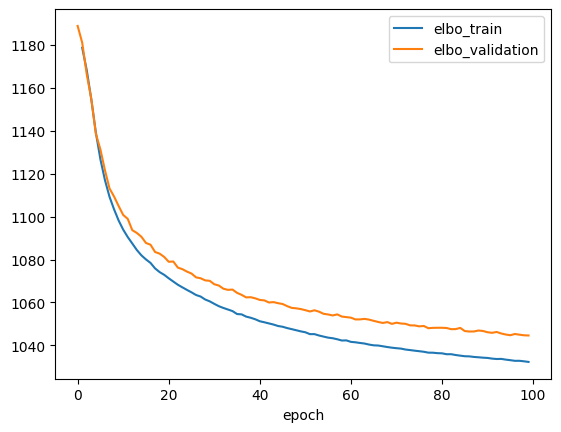

In [19]:
#plot training model to make sure it has converged 
ax = vae.history['elbo_train'][1:].plot()
vae.history['elbo_validation'].plot(ax=ax)


In [20]:
#setting up training model, check the 'class' or quivalent column is presetn in the refernce an merged object 
integrated.obs["celltype_scanvi"] = 'Unknown'
ref_idx = integrated.obs['batch'] == "reference"
integrated.obs.loc[ref_idx, "celltype_scanvi"] = integrated.obs.loc[ref_idx, 'cell_type'].astype(str) 


In [21]:
#who knows what this does maybe callum 
lvae = scvi.model.SCANVI.from_scvi_model(
    vae,
    adata=integrated,
    labels_key="celltype_scanvi",
    unlabeled_category="Unknown",
)

In [22]:
lvae.train(max_epochs=100, n_samples_per_label=100, early_stopping=True)

INFO     Training for 100 epochs.                                                                                  


/home/elliot/miniconda3/envs/atac_env/lib/python3.9/site-packages/lightning/fabric/plugins/environments/slurm.py:204: PossibleUserWarning:

The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/elliot/miniconda3/envs/atac_env/lib/python3.9/ ...

INFO: GPU available: False, used: False
2025-11-22 16:10:43 - INFO - GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
2025-11-22 16:10:43 - INFO - TPU available: False, using: 0 TPU cores
/home/elliot/miniconda3/envs/atac_env/lib/python3.9/site-packages/lightning/fabric/plugins/environments/slurm.py:204: PossibleUserWarning:

The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/elliot/miniconda3/envs/atac_env/lib/python3.9/ ...

/home/elliot/miniconda3/en

Epoch 100/100: 100%|██████████| 100/100 [41:59<00:00, 25.22s/it, v_num=1, train_loss_step=972, train_loss_epoch=999]    

INFO: `Trainer.fit` stopped: `max_epochs=100` reached.
2025-11-22 16:52:43 - INFO - `Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 100/100: 100%|██████████| 100/100 [41:59<00:00, 25.19s/it, v_num=1, train_loss_step=972, train_loss_epoch=999]


<Axes: xlabel='epoch'>

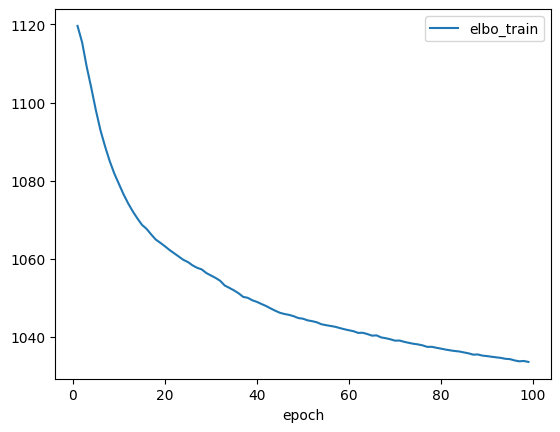

In [23]:
#plotting history as normal (if not saved)
lvae.history['elbo_train'][1:].plot()


In [24]:
# Now you can use the model
integrated.obs["C_scANVI"] = lvae.predict()
integrated.obsm["X_scANVI"] = lvae.get_latent_representation()

In [25]:
#generating uMAP
sc.pp.neighbors(integrated, use_rep="X_scANVI")
sc.tl.umap(integrated)

... storing 'cell_type' as categorical
... storing 'celltype_scanvi' as categorical
... storing 'C_scANVI' as categorical


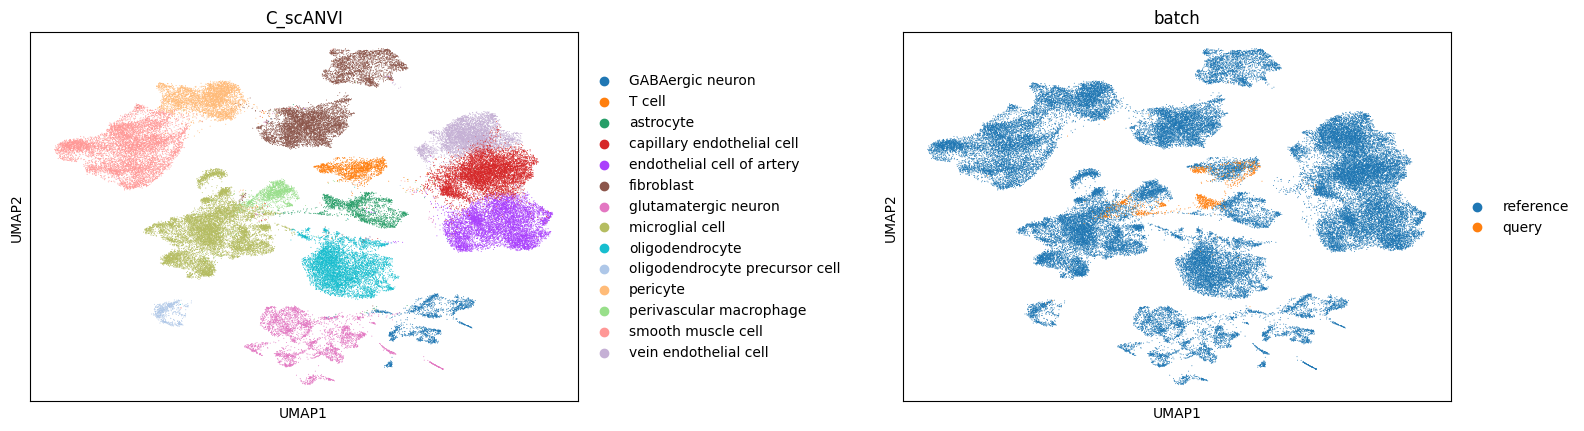

In [26]:
#Plotting uMAP querey and reference
sc.pl.umap(integrated, color=['C_scANVI', "batch"], wspace=0.45)


In [27]:
# Transfer predicted cell types back to original SnapATAC2 object
data.obs['cell_type'] = integrated.obs.loc[data.obs_names + '_query', 'C_scANVI'].to_numpy()

In [3]:
#load data 
data = sc.read_h5ad("/mnt/claw-raid/elliot/P002_mtscATAC-seq/data/processed/atac_PM_Ctx/annotated_PM.h5ad")

AttributeError: 'NoneType' object has no attribute 'name'

In [3]:
sc.pl.umap(data  , color=['cell_type', "leiden"], wspace=0.45)


AttributeError: 'builtins.AnnData' object has no attribute '_sanitize'

In [23]:
# Check var_names (gene names)
print(gene_matrix.var_names[:20])  # First 20 gene names

# Check if genes exist
for gene in ['P2RY12', 'CD3E', 'SOX10']:
    print(f"{gene} in var_names:", gene in gene_matrix.var_names)

# Check obs columns
print("\nobs columns:", list(gene_matrix.obs.columns))


Index(['ENSG00000223972.5', 'ENSG00000227232.5', 'ENSG00000243485.5',
       'ENSG00000284332.1', 'ENSG00000238009.6', 'ENSG00000279928.2',
       'ENSG00000279457.4', 'ENSG00000228463.10', 'ENSG00000286448.1',
       'ENSG00000230021.10', 'ENSG00000235146.2', 'ENSG00000228327.5',
       'ENSG00000237491.10', 'ENSG00000230092.7', 'ENSG00000177757.2',
       'ENSG00000225880.6', 'ENSG00000228794.12', 'ENSG00000288531.1',
       'ENSG00000230368.2', 'ENSG00000234711.1'],
      dtype='object')
P2RY12 in var_names: False
CD3E in var_names: False
SOX10 in var_names: False

obs columns: ['n_fragment', 'frac_dup', 'frac_mito', 'tsse', 'doublet_probability', 'doublet_score', 'leiden']


... storing 'leiden' as categorical
/home/elliot/miniconda3/envs/atac_env190516/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1267: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))


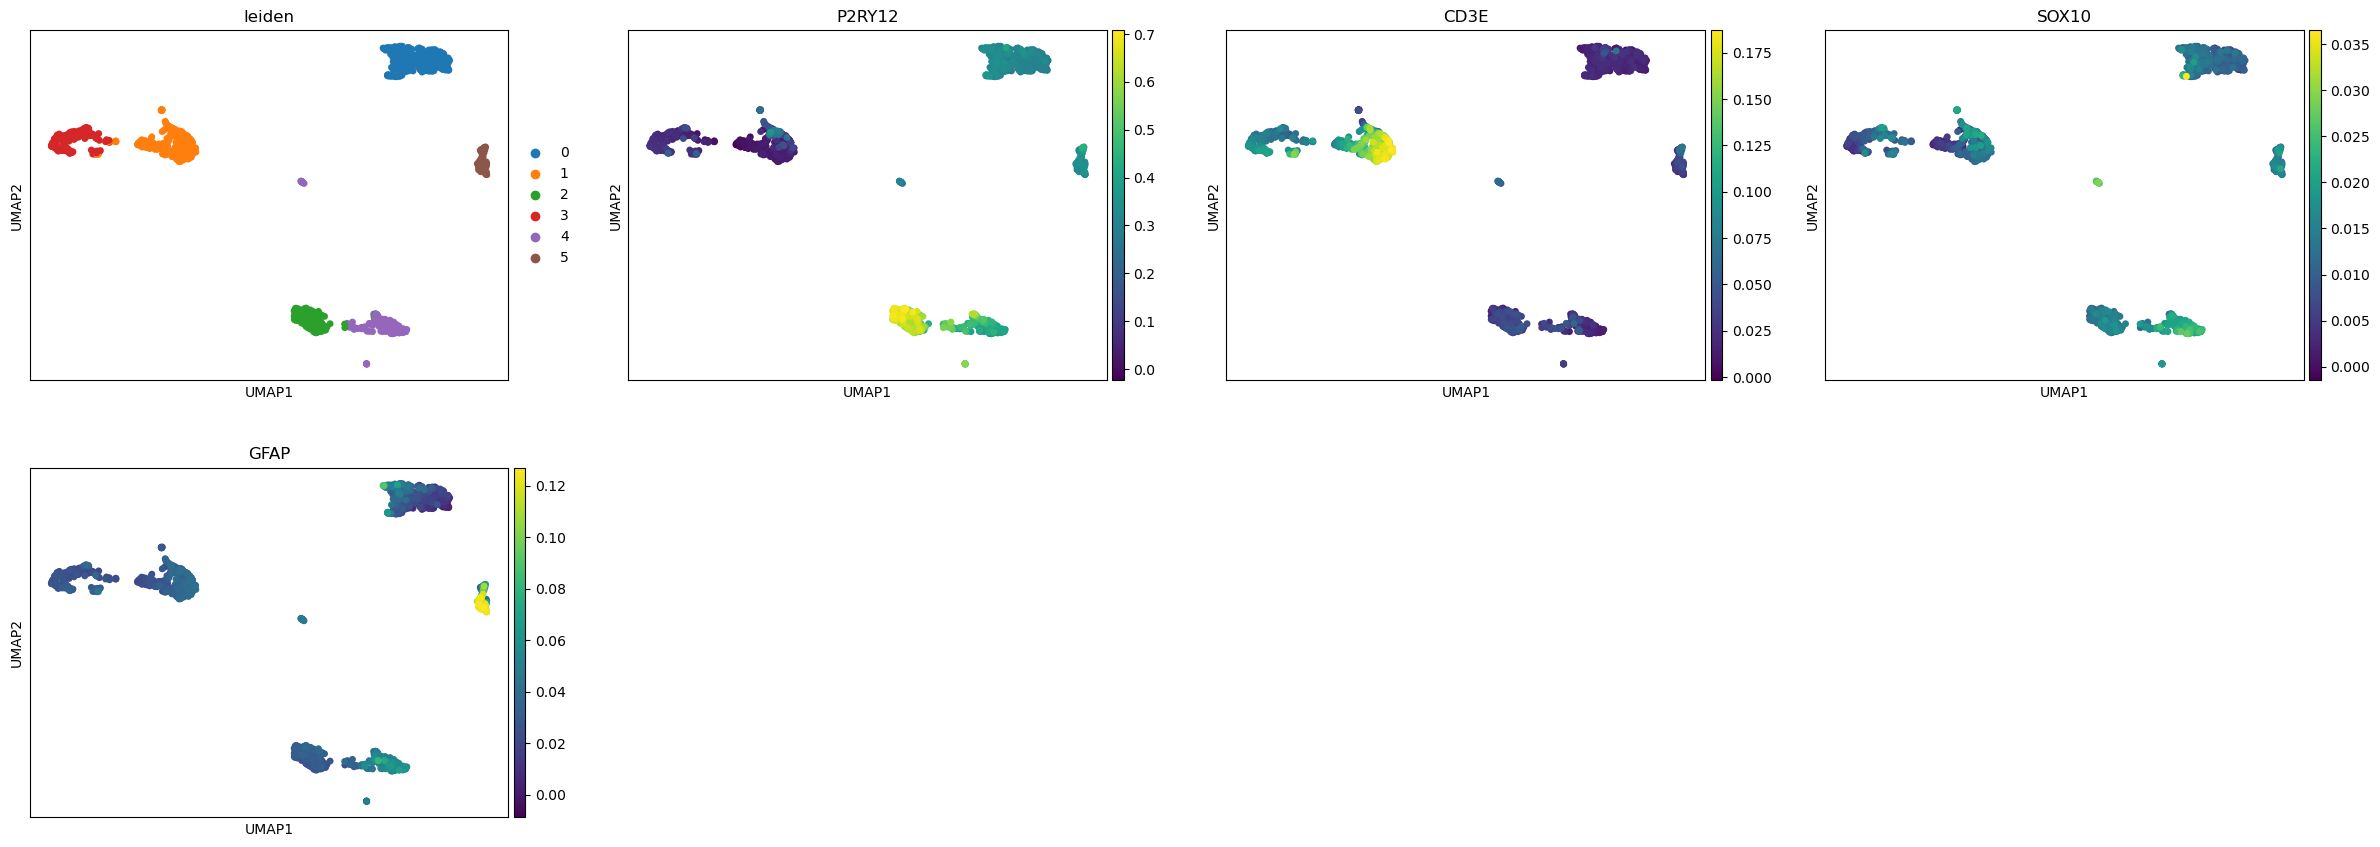

In [ ]:
gene_matrix = snap.pp.make_gene_matrix(
    data,                          # your loaded object
    gene_anno=snap.genome.hg38,
    gene_name_key='gene_name'
)
#Gene filtering, data normalisation + data transformation using Scanpy 
sc.pp.filter_genes(gene_matrix, min_cells=2)  # Filter genes expressed in fewer than 100 cells
sc.pp.normalize_total(gene_matrix)
sc.pp.log1p(gene_matrix)
sc.external.pp.magic(gene_matrix, solver="approximate")
gene_matrix.obsm["X_umap"] = data.obsm["X_umap"]
#plot genes on uMap
marker_genes = ['P2RY12', 'CD3E', 'SOX10', 'GFAP', 'CD206']   
sc.pl.umap(gene_matrix, use_raw=False, color=["leiden"] + marker_genes)

/home/elliot/miniconda3/envs/atac_env190516/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1267: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))


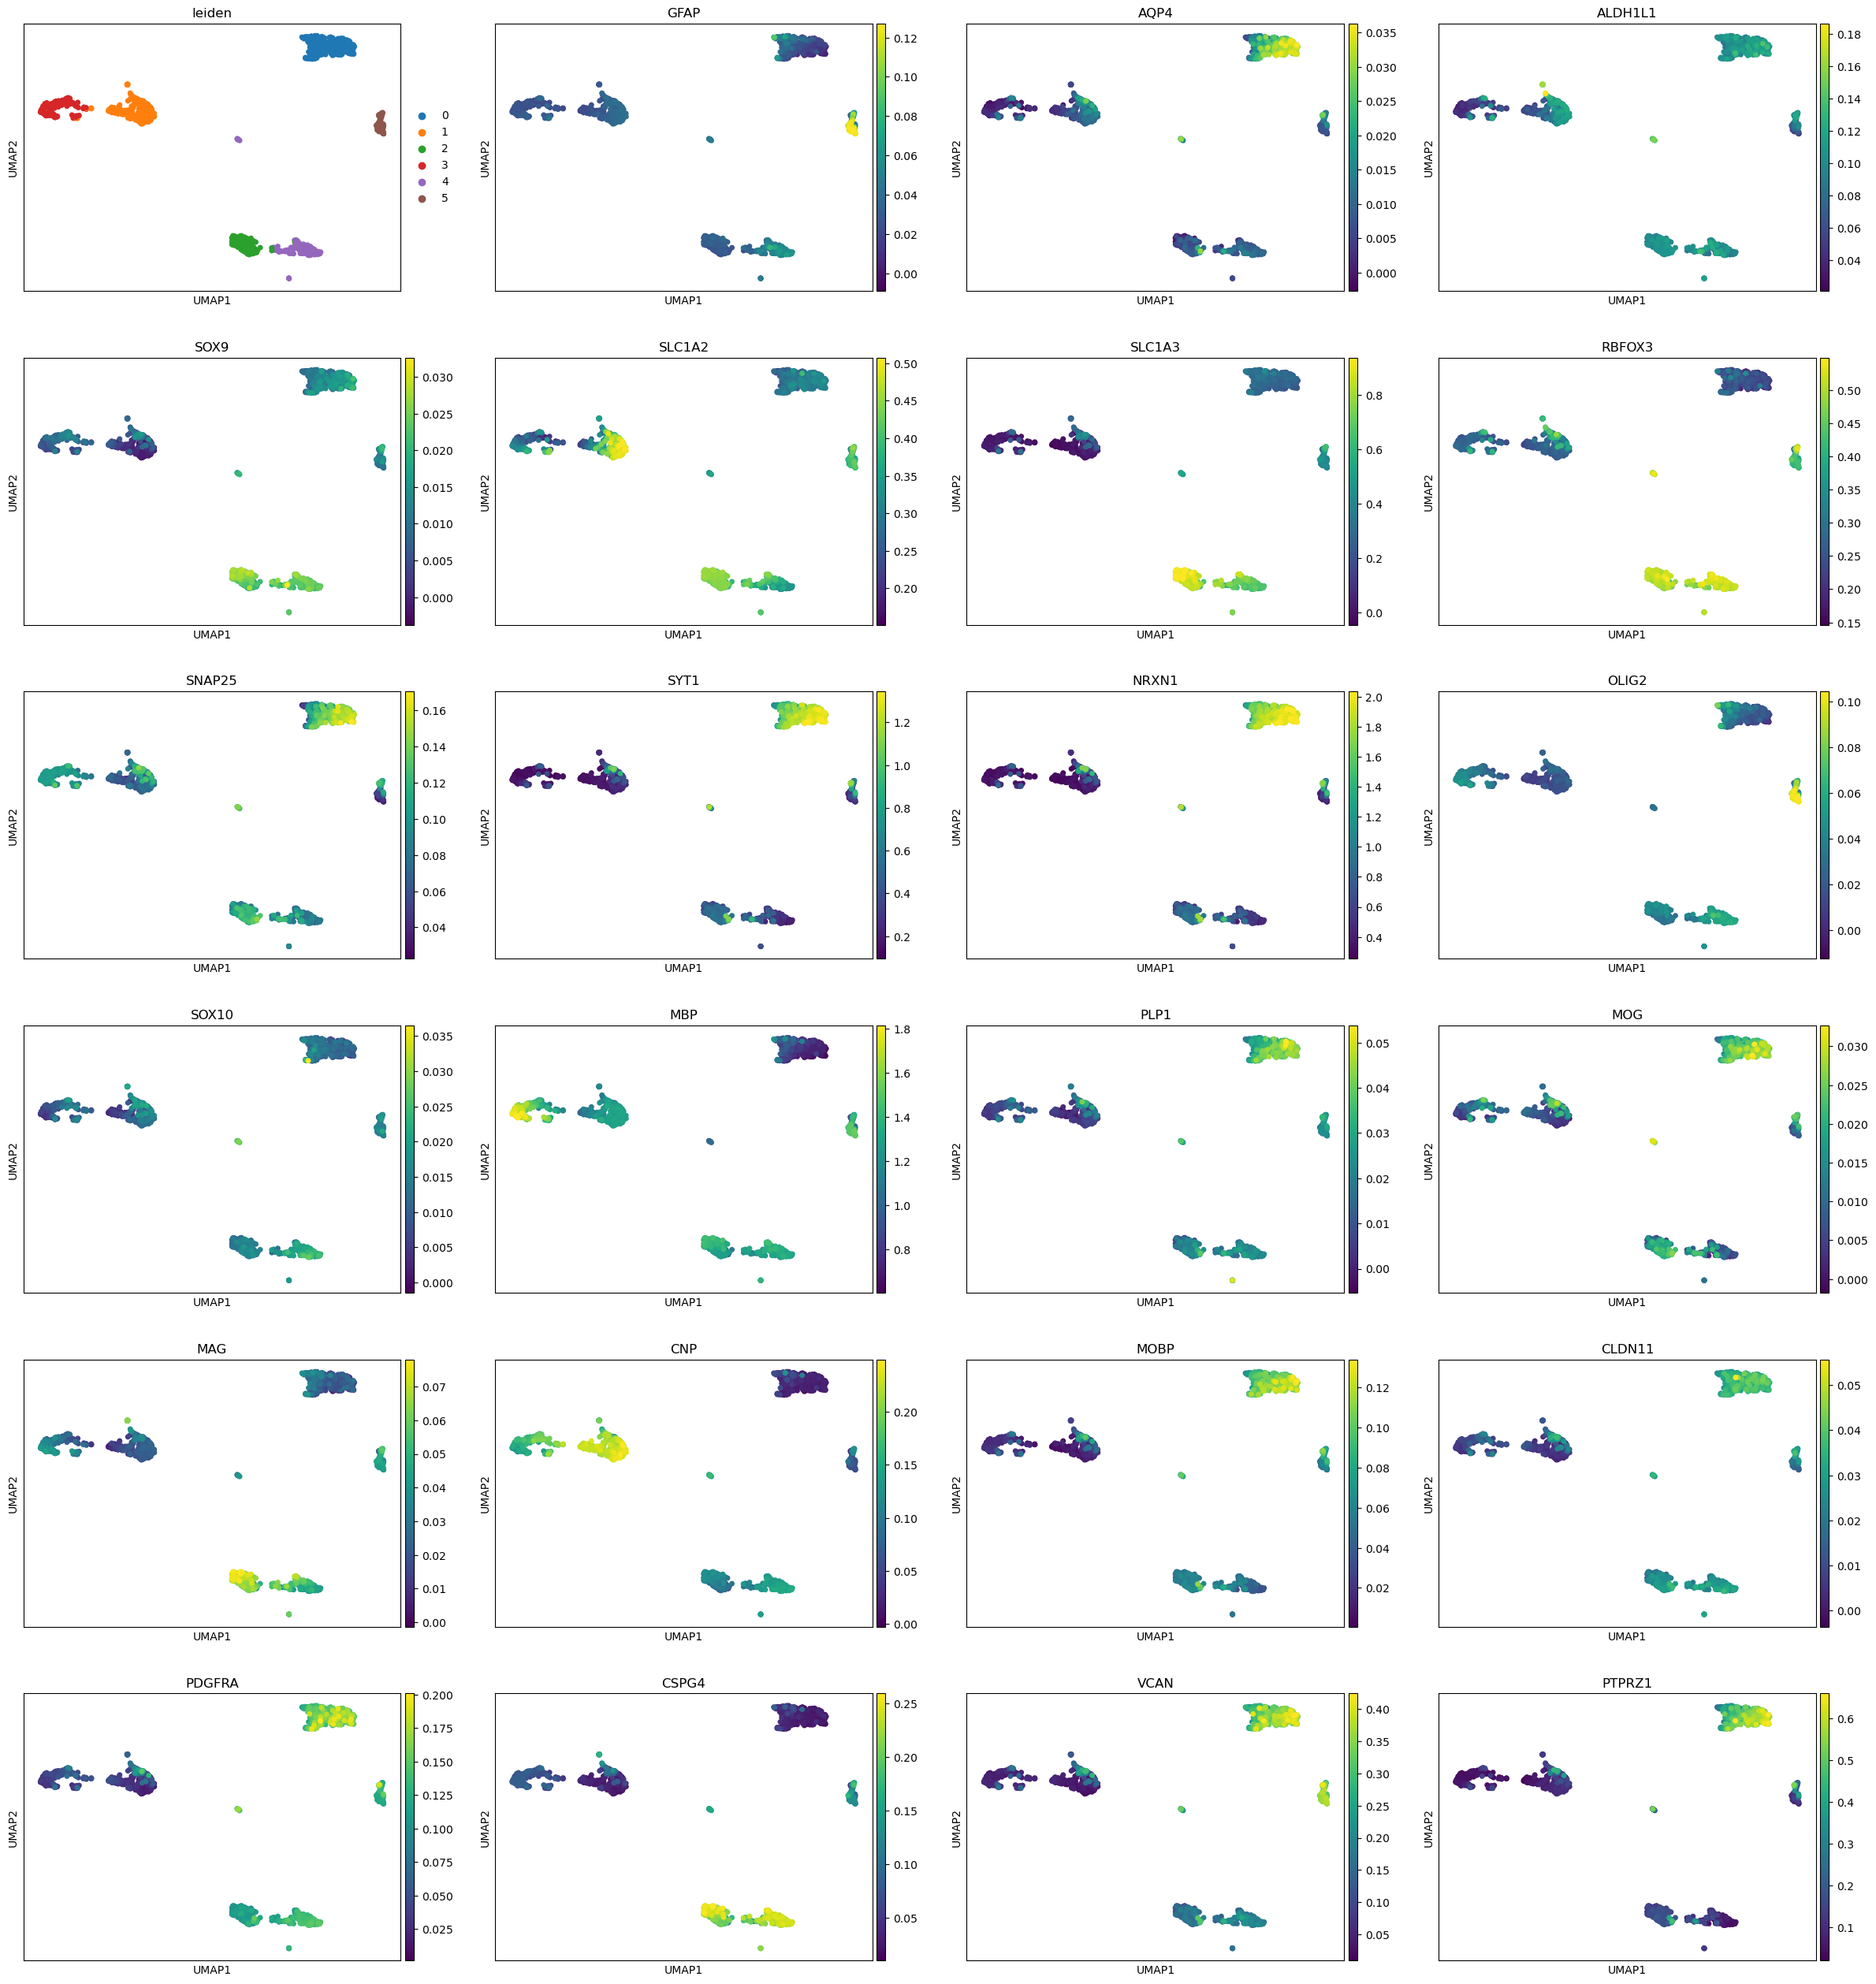

In [59]:
marker_genes = genes = [
    'GFAP', 'AQP4', 'ALDH1L1', 'SOX9', 'SLC1A2', 'SLC1A3',
    'RBFOX3', 'SNAP25', 'SYT1', 'NRXN1',
    'OLIG2', 'SOX10', 'MBP', 'PLP1', 'MOG', 'MAG', 'CNP', 'MOBP', 'CLDN11',
    'PDGFRA', 'CSPG4', 'VCAN', 'PTPRZ1'
]

sc.pl.umap(
    gene_matrix,
    color=['leiden'] + [g for g in marker_genes if g in gene_matrix.var_names],
    use_raw=False,
    ncols=4
)

In [ ]:
#Elliot - mkaing a DEGs list actually, gene_matrix is an object NOT an acutal matrix 

# Get the number of top genes (should be 20 based on your plot)
n_genes = len(gene_matrix.uns['rank_genes_groups']['names'])

# Create a dictionary with DEG lists for each cluster
deg_lists = {}
for i in range(n_genes):
    for j, cluster in enumerate(gene_matrix.uns['rank_genes_groups']['names'].dtype.names):
        if cluster not in deg_lists:
            deg_lists[cluster] = []
        deg_lists[cluster].append(gene_matrix.uns['rank_genes_groups']['names'][i][j])

# Now deg_lists contains clean lists of top DEGs for each cluster
for cluster, genes in deg_lists.items():
    print(f"Cluster {cluster}: {genes[:20]}...")  # Show first 5 genes

Cluster 0: ['LRP1B', 'GRID2', 'ENSG00000231918', 'CNTN5', 'CNTNAP2', 'DPP10', 'ENSG00000251574', 'EYS', 'ROBO2', 'ERBB4', 'DMD', 'NAALADL2', 'CSMD3', 'ENSG00000254394', 'CDH18', 'RBMS3', 'ROBO1', 'ENSG00000248752', 'SPAG16', 'CADM2']...
Cluster 1: ['PELATON', 'CDH23', 'ENSG00000285565', 'RAD51B', 'PSAP', 'DAPK1', 'SLC24A4', 'PGS1', 'ENSG00000234261', 'PFKFB3', 'ZMIZ1', 'ENSG00000273112', 'HSPD1', 'MGAT1', 'BAG3', 'MBP', 'HSPH1', 'ENSG00000285016', 'DNAJB6', 'XYLT1']...
Cluster 2: ['ENSG00000234261', 'LINC00877', 'SCIRT', 'ENSG00000258137', 'HK2', 'JARID2', 'ZMIZ1', 'ENSG00000258086', 'CUX1', 'PRKAG2', 'RBM47', 'RIN2', 'SLCO3A1', 'GAS7', 'RFX2', 'NCOR2', 'TIMP2', 'ENSG00000289728', 'DMXL2', 'FNDC3B']...
Cluster 3: ['HK2', 'CUX1', 'FNDC3B', 'RUNX1', 'PRKAG2', 'MAML3', 'JARID2', 'ASAP1', 'ENSG00000289728', 'DOCK5', 'ENSG00000259345', 'SLCO3A1', 'RPTOR', 'SLC24A4', 'ENSG00000286022', 'IGF2BP2', 'DOCK2', 'PPARG', 'LUCAT1', 'NIBAN2']...
Cluster 4: ['BCL11B', 'RORA', 'RORA-AS1', 'SCML4', 'ITK

... storing 'leiden' as categorical


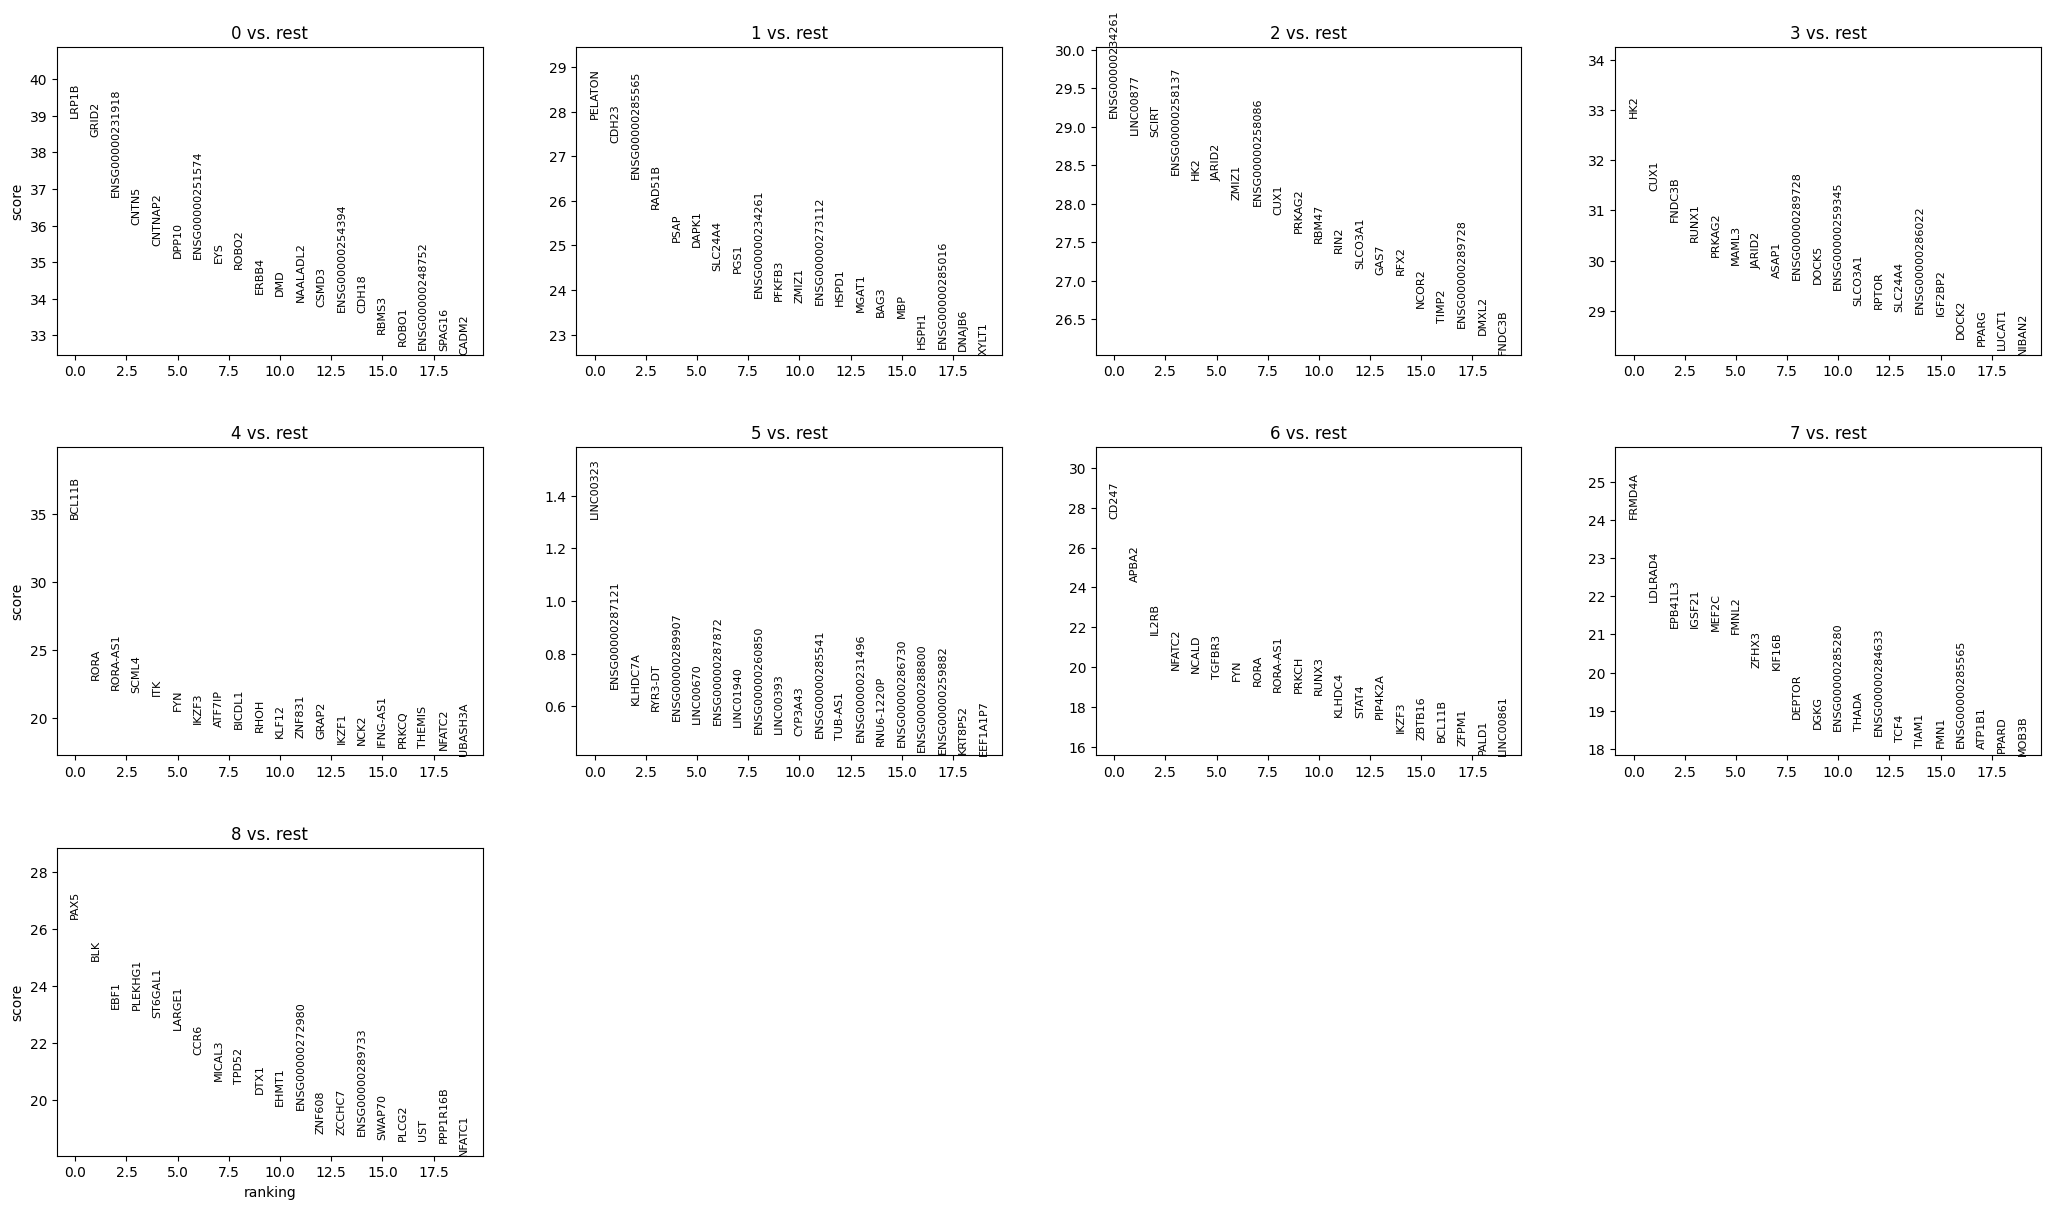

In [ ]:
# Run differential expression analysis between clusters (e.g., 'leiden' clusters)
sc.tl.rank_genes_groups(gene_matrix, groupby='leiden', method='wilcoxon')

# Show the top marker genes for each cluster
sc.pl.rank_genes_groups(gene_matrix, n_genes=20, sharey=False)



In [ ]:
# !!!!!!!!!!!!!!!!!! !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!OK SO NOW THE MT VARIANT CALLING BEGINS STOP HERE !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

In [ ]:
import sys
sys.path.insert(0, '/mnt/claw-raid/elliot/P002_mtscATAC-seq/scripts/Py_mTCall_tools')
import variant_calling_fast as vc
mgatk = vc.process_variants_fast("/mnt/claw-raid/elliot/P002_mtscATAC-seq/data/raw/241121-cortex_results_masked/mgatk_output/final", data, verbose=True, coverage_threshold=10, min_strand_count=1)





=== Fast Variant Calling Pipeline ===


You'll find variant names in adata.uns['variant_names']

Find coverage PER cell in adata.obsm['coverage_per_cell']

Variant summmary stats similar to Signac are in adata.uns['variant_summary']

Variant matrices are in adata.obsm["variant_vaf"]


=== IMPORTANT NOTE ===

Remember that variant VAFs are only included if they pass the min_strand_count filter

AND the coverage threshold if specified!





KeyboardInterrupt: 

In [86]:
mgatk = sc.read_h5ad("/mnt/claw-raid/elliot/P002_mtscATAC-seq/data/processed/atac_PM_Ctx/mgatk_analysis.h5ad")

In [52]:
import anndata, numpy as np

vn = mgatk.uns["variant_names"]
vaf = mgatk.obsm["variant_vaf"]

# Keep variants with mean VAF >= 0.50
idx = np.where(np.mean(vaf, axis=0) >= 0.01)[0]

# Format: position + REF allele only (no >)
variants = [f"{v.split('-')[1]}{v.split('-')[0]}" for v in vn[idx]]

# Save in proper hsd format
with open("/mnt/claw-raid/elliot/mgatk_variants.hsd", "w") as f:
    f.write("sample_id\t1-16569\t?\t" + "\t".join(variants))

print(f"Saved {len(variants)} variants")
print("Variants:", variants)

Saved 33 variants
Variants: ['11719A', '16255A', '1719A', '225A', '14470C', '195C', '1969A', '16519C', '310C', '6371T', '14766T', '3107C', '3107T', '1824C', '6221C', '12705T', '16223T', '16189C', '7028T', '8705C', '16278T', '16183C', '4769G', '2706G', '13966G', '1438G', '750G', '153G', '15326G', '227G', '263G', '73G', '8860G']


variants kept: 1054
cells kept: 1212
variants excluded: 29
Excluded positions found in kept variants: set()

All remaining variants with mean VAF > 5%:


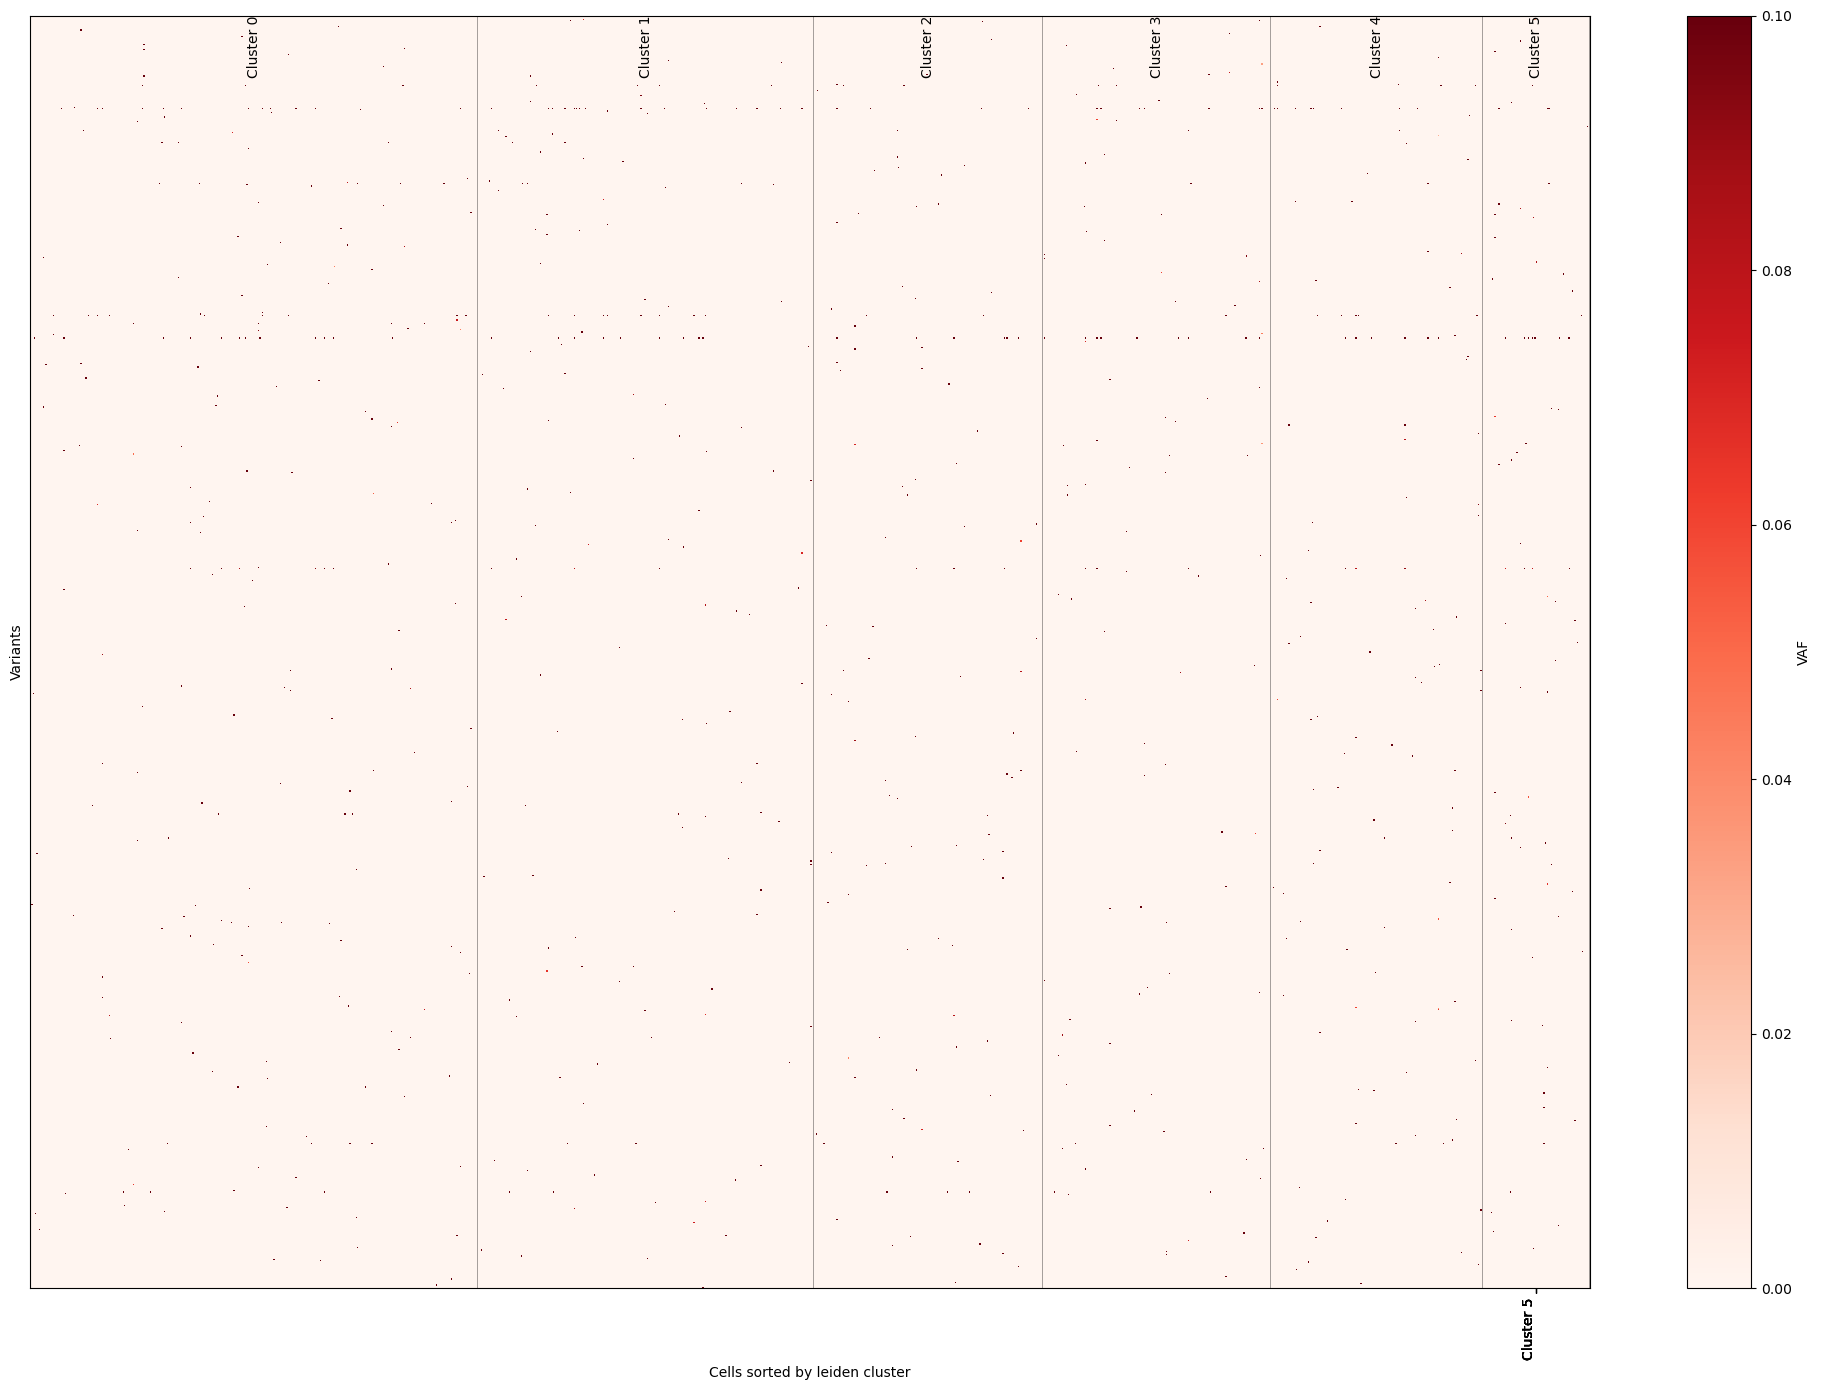

In [78]:
import numpy as np
import matplotlib.pyplot as plt


X_positions = np.array([73, 153, 195, 225, 227, 263, 750, 1438, 1719, 2706, 4769, 6221, 6371, 16519, 1824, 16183, 7028, 8705, 8860, 11719, 12705, 13966, 14470, 14766, 15326, 16189, 16223, 16255, 16278])


def get_pos(v):
    try:
        return int(v.split("-")[1])
    except:
        return -1



variant_names = np.array(mgatk.uns["variant_names"])
positions = np.array([get_pos(v) for v in variant_names])



keep = ~np.isin(positions, X_positions)



variant_names_kept = variant_names[keep]
vaf = mgatk.obsm["variant_vaf"][:, keep]



cell_types = mgatk.obs["cell_type"].astype(str).values

leiden_clusters = mgatk.obs["leiden"].values
cell_order = np.argsort(leiden_clusters)

vaf = vaf[cell_order, :]
cell_types_sorted = cell_types[cell_order]
leiden_sorted = leiden_clusters[cell_order]


print("variants kept:", len(variant_names_kept))
print("cells kept:", len(cell_types_sorted))
print("variants excluded:", len(positions) - len(positions[keep]))


print("Excluded positions found in kept variants:", 
      set(positions[keep]) & set(X_positions))

# Calculate VAF stats for ALL remaining variants
mean_vaf = np.mean(vaf, axis=0)
percent_cells_high = np.mean(vaf > 0.05, axis=0) * 100
percent_cells_any = np.mean(vaf > 0.01, axis=0) * 100

# Print ALL variants with mean VAF > 5% (showing the one you're seeing)
print("\nAll remaining variants with mean VAF > 5%:")
high_vaf_indices = np.where(mean_vaf > 0.05)[0]
for idx in high_vaf_indices:
    var = variant_names_kept[idx]
    print(f"  {var}: {mean_vaf[idx]*100:.2f}% mean VAF, {percent_cells_high[idx]:.1f}% cells > 5%, {percent_cells_any[idx]:.1f}% cells > 1%")

# Find cluster boundaries
unique_leiden = np.unique(leiden_sorted)
cluster_boundaries = []
for cluster in unique_leiden:
    cluster_indices = np.where(leiden_sorted == cluster)[0]
    cluster_boundaries.append((cluster, cluster_indices[0], cluster_indices[-1]))


fig, ax = plt.subplots(figsize=(20, 14))
im = ax.imshow(vaf.T, cmap="Reds", aspect="auto", vmin=0, vmax=0.1, interpolation="nearest")

for cluster_idx, (cluster, start, end) in enumerate(cluster_boundaries):
    ax.axvline(end, color='black', linestyle='-', linewidth=0.5, alpha=0.5)
    center = (start + end) / 2
    ax.text(center, -0.1, f'Cluster {cluster}', ha='center', va='top', fontsize=10, rotation=90)

ax.set_xticks([center for cluster, start, end in cluster_boundaries])
ax.set_xticklabels([f'Cluster {cluster}' for cluster, start, end in cluster_boundaries], rotation=90, ha='right')

ax.set_xlabel("Cells sorted by leiden cluster")
ax.set_ylabel("Variants")
ax.set_yticks([])
plt.colorbar(im, ax=ax, label="VAF")
plt.tight_layout()
plt.show()

Total variants: 1083
Variants after filtering: 1054
Number excluded: 29

VAF threshold: 5.0% (appropriate for 13x coverage)

Variants per cell stats:
Mean: 0.6658415841584159
Min: 0
Max: 7

PM Summary by cell type (VAF ≥ 5.0%, excluding haplogroup markers):
                      mean       std  count       sem
cell_type                                            
HomeoMcg          0.721212  1.140111    165  0.088757
InfMcg            0.623596  1.046330    178  0.078426
Macrophages       0.891566  1.396966     83  0.153337
Oligodendrocytes  0.658046  1.016163    348  0.054472
T cells           0.625571  1.089364    438  0.052052


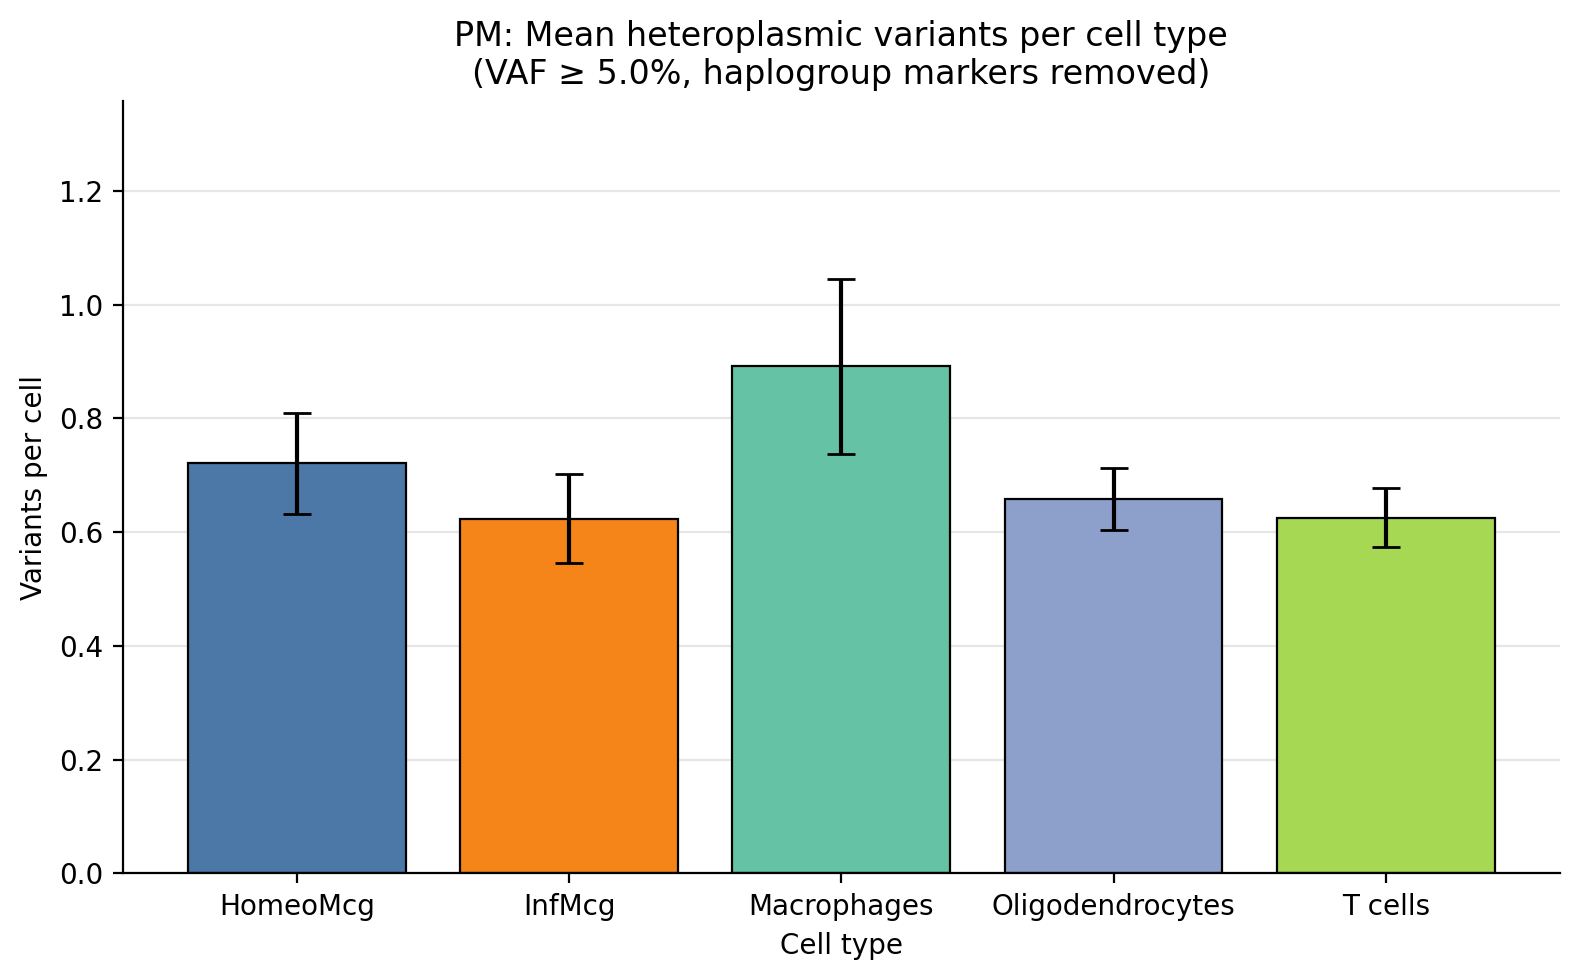

In [106]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


adata = mgatk


X_positions = np.array([73, 153, 195, 225, 227, 263, 750, 1438, 1719, 2706, 4769, 6221, 6371, 16519, 1824, 16183, 7028, 8705, 8860, 11719, 12705, 13966, 14470, 14766, 15326, 16189, 16223, 16255, 16278])


vaf = adata.obsm["variant_vaf"]
conf = adata.obsm["variant_confident"].astype(bool)


variant_names = np.array(adata.uns["variant_names"]).astype(str)
variant_pos = np.array([
    int(re.search(r"(\d+)", x).group(1)) if re.search(r"(\d+)", x) else np.nan
    for x in variant_names
])


keep = (~np.isnan(variant_pos)) & (~np.isin(variant_pos, X_positions))


vaf_f = vaf[:, keep]
conf_f = conf[:, keep]


print("Total variants:", vaf.shape[1])
print("Variants after filtering:", vaf_f.shape[1])
print("Number excluded:", vaf.shape[1] - vaf_f.shape[1])


# PM has 13x coverage, so use 15% VAF threshold (2/13 reads = 15.4%)
# This is the minimum detectable heteroplasmy at this coverage
VAF_THRESHOLD = 0.05
variants_per_cell = ((vaf_f >= VAF_THRESHOLD) & conf_f).sum(axis=1)


print(f"\nVAF threshold: {VAF_THRESHOLD*100}% (appropriate for 13x coverage)")
print("\nVariants per cell stats:")
print("Mean:", variants_per_cell.mean())
print("Min:", variants_per_cell.min())
print("Max:", variants_per_cell.max())


leiden = adata.obs["leiden"].astype(str).values
cell_type = np.where(np.isin(leiden, ["3", "1"]), "T cells",
            np.where(leiden == "4", "HomeoMcg",
            np.where(leiden == "2", "InfMcg",
            np.where(leiden == "0", "Oligodendrocytes",
            np.where(leiden == "5", "Macrophages", leiden)))))


df = pd.DataFrame({
    "cell_type": cell_type,
    "variants_per_cell": variants_per_cell.astype(float)
})


order = ["HomeoMcg", "InfMcg", "Macrophages", "Oligodendrocytes", "T cells"]
order = [x for x in order if x in df["cell_type"].unique()]


summary = df.groupby("cell_type")["variants_per_cell"].agg(["mean", "std", "count"]).reindex(order)
summary["sem"] = summary["std"] / np.sqrt(summary["count"])


print(f"\nPM Summary by cell type (VAF ≥ {VAF_THRESHOLD*100}%, excluding haplogroup markers):")
print(summary)


colors = {
    "HomeoMcg": "#4C78A8",
    "InfMcg": "#F58518",
}
fallback = plt.cm.Set2(np.linspace(0, 1, max(1, len(order))))
fi = 0
for g in order:
    if g not in colors:
        colors[g] = fallback[fi]
        fi += 1


fig, ax = plt.subplots(figsize=(8, 5), dpi=200)


ax.bar(
    order,
    summary["mean"].values,
    yerr=summary["sem"].values,
    capsize=5,
    color=[colors[g] for g in order],
    edgecolor="black",
    linewidth=0.8,
    ecolor="black"
)


ax.set_xlabel("Cell type")
ax.set_ylabel("Variants per cell")
ax.set_title(f"PM: Mean heteroplasmic variants per cell type\n(VAF ≥ {VAF_THRESHOLD*100}%, haplogroup markers removed)")
ax.set_ylim(0, max(summary["mean"] + summary["sem"]) * 1.3 if len(summary) else 1)
ax.grid(axis="y", color="0.9", linewidth=0.8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_axisbelow(True)


plt.tight_layout()
plt.show()

In [104]:
print("Confident fraction:", conf.mean())
print("VAF >= 5% fraction:", (vaf_f >= 0.05).mean())

Confident fraction: 0.015350496268463411
VAF >= 5% fraction: 0.0006317282582148158


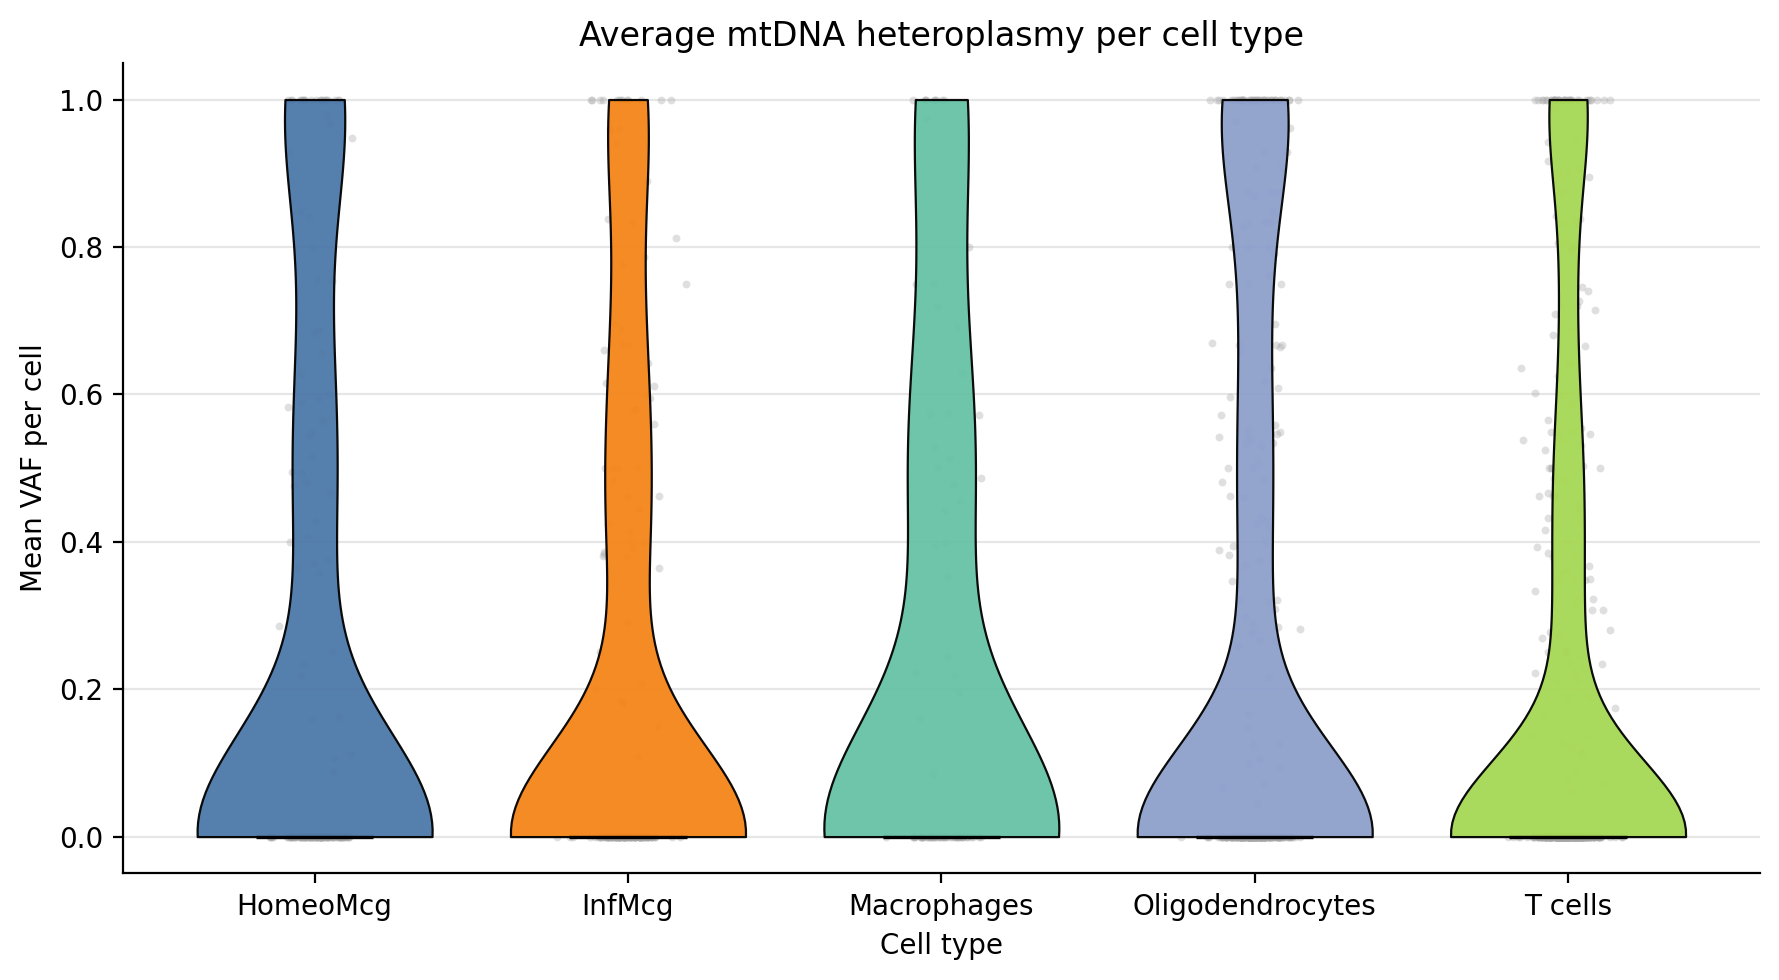

In [107]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

adata = mgatk

X_positions = np.array([73, 153, 195, 225, 227, 263, 750, 1438, 1719, 2706, 4769, 6221, 6371, 16519, 1824, 16183, 7028, 8705, 8860, 11719, 12705, 13966, 14470, 14766, 15326, 16189, 16223, 16255, 16278])

vaf = adata.obsm["variant_vaf"]
conf = adata.obsm["variant_confident"].astype(bool)

variant_names = np.array(adata.uns["variant_names"]).astype(str)
variant_pos = np.array([
    int(re.search(r"(\d+)", x).group(1)) if re.search(r"(\d+)", x) else np.nan
    for x in variant_names
])

keep = (~np.isnan(variant_pos)) & (~np.isin(variant_pos, H_positions))

vaf_f = vaf[:, keep]
conf_f = conf[:, keep]

mean_vaf_conf = np.divide(
    (vaf_f * conf_f).sum(axis=1),
    conf_f.sum(axis=1),
    out=np.zeros(vaf_f.shape[0], dtype=float),
    where=conf_f.sum(axis=1) > 0
)

leiden = adata.obs["leiden"].astype(str).values
cell_type = np.where(np.isin(leiden, ["3", "1"]), "T cells",
            np.where(leiden == "4", "HomeoMcg",
            np.where(leiden == "2", "InfMcg",
            np.where(leiden == "0", "Oligodendrocytes",
            np.where(leiden == "5", "Macrophages", leiden)))))

df = pd.DataFrame({
    "cell_type": cell_type,
    "mean_vaf_conf_noH": mean_vaf_conf,
    "n_fragment": adata.obs["n_fragment"].to_numpy()
})

df = df[df["n_fragment"] >= 10].copy()

order = ["HomeoMcg", "InfMcg", "Macrophages", "Oligodendrocytes", "T cells"]
order = [x for x in order if x in df["cell_type"].unique()]

colors = {
    "HomeoMcg": "#4C78A8",
    "InfMcg": "#F58518",
}
fallback = plt.cm.Set2(np.linspace(0, 1, max(1, len(order))))
fallback_i = 0
for o in order:
    if o not in colors:
        colors[o] = fallback[fallback_i]
        fallback_i += 1

fig, ax = plt.subplots(figsize=(9, 5), dpi=200)
rng = np.random.default_rng(0)

for i, cl in enumerate(order, start=1):
    y = df.loc[df["cell_type"] == cl, "mean_vaf_conf_noH"].to_numpy(dtype=float)
    x = rng.normal(i, 0.06, size=len(y))
    ax.scatter(x, y, s=8, c="0.65", alpha=0.35, linewidths=0, zorder=1)

data = [df.loc[df["cell_type"] == cl, "mean_vaf_conf_noH"].to_numpy(dtype=float) for cl in order]
parts = ax.violinplot(
    data,
    positions=np.arange(1, len(order) + 1),
    widths=0.75,
    showmedians=True,
    showextrema=False
)

for body, cl in zip(parts["bodies"], order):
    body.set_facecolor(colors[cl])
    body.set_edgecolor("black")
    body.set_linewidth(0.8)
    body.set_alpha(0.95)
    body.set_zorder(2)

parts["cmedians"].set_color("black")
parts["cmedians"].set_linewidth(1.2)

ax.set_xticks(np.arange(1, len(order) + 1))
ax.set_xticklabels(order)
ax.set_xlabel("Cell type")
ax.set_ylabel("Mean VAF per cell")
ax.set_title("Average mtDNA heteroplasmy per cell type")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", color="0.9", linewidth=0.8)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

In [83]:
summary = df.groupby("cell_type")["mean_vaf_conf_noH"].agg(["count", "mean", "median", "min", "max"])
print(summary.loc[order])

                  count      mean  median  min  max
cell_type                                          
HomeoMcg            165  0.259047     0.0  0.0  1.0
InfMcg              178  0.225795     0.0  0.0  1.0
Macrophages          83  0.261561     0.0  0.0  1.0
Oligodendrocytes    348  0.275130     0.0  0.0  1.0
T cells             438  0.209165     0.0  0.0  1.0


In [15]:
#Filter vars per tissue BEFORE making long matrix with untion list 
import pandas as pd

vaf_matrix = mgatk.obsm['variant_vaf']
cell_names = mgatk.obs.index
variant_names = pd.Index(mgatk.uns['variant_names'])

# Leiden cell filter
leiden_clusters_to_keep = ['0','1','2','3','4','5']  # Adjust based on your clusters of interest
keep_cells_mask = mgatk.obs['leiden'].isin(leiden_clusters_to_keep)
keep_cells = mgatk.obs.index[keep_cells_mask]

print(f"Cells BEFORE leiden filter: {len(cell_names)}")
print(f"Cells AFTER leiden filter:  {len(keep_cells)}")

# Filter matrices to leiden cells
vaf_leiden = vaf_matrix[keep_cells_mask]
cov_leiden = mgatk.obsm['variant_coverage'][keep_cells_mask]

# *** FIXED: Combined mask - leiden signal AND high confidence ***
conf_stats = mgatk.uns['variant_summary']
high_conf_mask = conf_stats['n_cells_conf_detected'] >= 1

# Leiden-specific signal in high-conf vars only
leiden_signal_in_conf = (vaf_leiden[:, high_conf_mask] > 0).any(axis=0)
leiden_high_conf_vars = variant_names[high_conf_mask][leiden_signal_in_conf]

print(f"High-conf variants total:     {high_conf_mask.sum()}")
print(f"High-conf + leiden signal:   {len(leiden_high_conf_vars)}")



Cells BEFORE leiden filter: 1212
Cells AFTER leiden filter:  1212
High-conf variants total:     1083
High-conf + leiden signal:   590


positive_clusters: ['0', '1', '2', '3', '4', '5']
          mean  median  count
leiden                       
0       0.6065  0.7493    348
1       0.6673  0.8728    261
2       0.5842  0.7292    178
3       0.6444  0.8666    177
4       0.5946  0.7394    165
5       0.5930  0.8682     83

Top blood-position variants by positive cluster:

cluster 0
  variant   delta  log2_rr  in_rate  out_rate
G-13966-A  0.0086   0.0185   0.6753    0.6667
 C-8705-T -0.0008  -0.0018   0.6092    0.6100
 A-1719-G -0.0019  -0.0045   0.6092    0.6111
 C-6221-T -0.0142  -0.0322   0.6293    0.6435
A-16255-G -0.0243  -0.0584   0.5891    0.6134
 T-6371-C -0.0326  -0.0755   0.6063    0.6389
 C-1824-T -0.0398  -0.0976   0.5690    0.6088
T-16278-C -0.0455  -0.1143   0.5517    0.5972

cluster 1
  variant  delta  log2_rr  in_rate  out_rate
 C-6221-T 0.0835   0.1819   0.7050    0.6215
 C-8705-T 0.0677   0.1554   0.6628    0.5952
A-16255-G 0.0670   0.1547   0.6590    0.5920
 T-6371-C 0.0669   0.1488   0.6820    0.6151

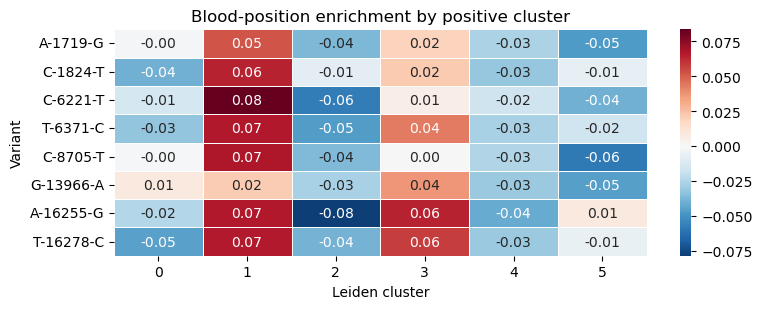


Presence of blood variants by positive cluster:
               0      1      2      3      4      5
G-13966-A  0.675  0.686  0.646  0.701  0.642  0.627
C-8705-T   0.609  0.663  0.579  0.610  0.588  0.554
A-1719-G   0.609  0.651  0.579  0.627  0.588  0.566
C-6221-T   0.629  0.705  0.590  0.644  0.624  0.602
A-16255-G  0.589  0.659  0.539  0.661  0.570  0.614
T-6371-C   0.606  0.682  0.590  0.667  0.606  0.614
C-1824-T   0.569  0.648  0.590  0.616  0.570  0.590
T-16278-C  0.552  0.636  0.551  0.633  0.558  0.578


In [85]:
import pandas as pd
import numpy as np
import re
import seaborn as sns
import matplotlib.pyplot as plt

def pos_from_variant(v):
    m = re.search(r'-(\d+)-', str(v).strip())
    return m.group(1) if m else None

# use existing blood score and UMAP object
obs = mgatk.obs.copy()
obs["leiden"] = obs["leiden"].astype(str)

variant_names = pd.Index(mgatk.uns["variant_names"]).astype(str)
mat = mgatk.obsm["variant_counts"] if "variant_counts" in mgatk.obsm else mgatk.obsm["variant_vaf"]
X = pd.DataFrame(mat, index=mgatk.obs_names, columns=variant_names)
threshold = 2 if "variant_counts" in mgatk.obsm else 0.05

# positive clusters only
cluster_stats = obs.groupby("leiden", observed=True)["blood_weighted_score"].agg(["mean", "median", "count"]).sort_index()
pos_clusters = cluster_stats[cluster_stats["median"] > 0].index.tolist()

print("positive_clusters:", pos_clusters)
print(cluster_stats.round(4).to_string())

# binary variant presence matrix
V = (X >= threshold).astype(int)

# cluster-level enrichment
results = []
for cl in pos_clusters:
    in_cells = obs.index[obs["leiden"] == cl]
    out_cells = obs.index[obs["leiden"] != cl]

    in_rate = V.loc[in_cells].mean(axis=0)
    out_rate = V.loc[out_cells].mean(axis=0)

    df = pd.DataFrame({
        "variant": variant_names,
        "pos": [pos_from_variant(v) for v in variant_names],
        "cluster": cl,
        "in_rate": in_rate.values,
        "out_rate": out_rate.values,
    })
    df["delta"] = df["in_rate"] - df["out_rate"]
    df["log2_rr"] = np.log2((df["in_rate"] + 1e-6) / (df["out_rate"] + 1e-6))
    df = df.sort_values(["delta", "log2_rr", "in_rate"], ascending=[False, False, False])
    results.append(df)

enrichment = pd.concat(results, ignore_index=True)

# focus on the blood-associated positions you already found
blood_positions = {"1719", "6221", "6371", "8705", "1824", "13966", "16255", "16278"}
enrichment_blood = enrichment[enrichment["pos"].isin(blood_positions)].copy()

# top variants per positive cluster
top_by_cluster = (
    enrichment_blood.sort_values(["cluster", "delta", "log2_rr"], ascending=[True, False, False])
    .groupby("cluster")
    .head(10)
)

print("\nTop blood-position variants by positive cluster:")
for cl in pos_clusters:
    sub = top_by_cluster[top_by_cluster["cluster"] == cl]
    print(f"\ncluster {cl}")
    print(sub[["variant", "delta", "log2_rr", "in_rate", "out_rate"]].round(4).to_string(index=False))

# cluster x variant heatmap for blood positions
heat = enrichment_blood.pivot_table(index="variant", columns="cluster", values="delta", aggfunc="max").fillna(0)

# keep variants in a stable biologic order
order = [v for v in [
    "A-1719-G", "C-1824-T", "C-6221-T", "T-6371-C",
    "C-8705-T", "G-13966-A", "A-16255-G", "T-16278-C"
] if v in heat.index] + [v for v in heat.index if v not in {
    "A-1719-G", "C-1824-T", "C-6221-T", "T-6371-C",
    "C-8705-T", "G-13966-A", "A-16255-G", "T-16278-C"
}]
heat = heat.loc[order]

plt.figure(figsize=(8, max(3, 0.4 * len(heat))))
sns.heatmap(heat, cmap="RdBu_r", center=0, annot=True, fmt=".2f", linewidths=0.5)
plt.title("Blood-position enrichment by positive cluster")
plt.xlabel("Leiden cluster")
plt.ylabel("Variant")
plt.tight_layout()
plt.show()

# variant overlap table
presence_by_cluster = {}
for cl in pos_clusters:
    in_cells = obs.index[obs["leiden"] == cl]
    presence_by_cluster[cl] = V.loc[in_cells, list(enrichment_blood["variant"].unique())].mean(axis=0)

presence_df = pd.DataFrame(presence_by_cluster)
print("\nPresence of blood variants by positive cluster:")
print(presence_df.round(3).to_string())

In [118]:
import numpy as np
import csv

# Build matrices using union_vars
union_mask = np.isin(variant_names, union_vars)
final_variants = np.array(variant_names)[union_mask]


overall_coverage_df = pd.DataFrame(
    data=cov_leiden[:, union_mask],
    index=keep_cells,
    columns=final_variants
)


phylogeny_df = pd.DataFrame(
    data=vaf_leiden[:, union_mask],
    index=keep_cells,
    columns=final_variants
)


# Median depth filter per cell
coverage_final = overall_coverage_df.values
median_d_final = np.median(coverage_final, axis=1)
good_cells_mask = median_d_final >= 0
keep_cells_final = overall_coverage_df.index[good_cells_mask]


print(f"Cells AFTER median_d >= 10 filter: {len(keep_cells_final)} / {len(keep_cells)}")


# Direct long table with all cell × variant pairs using numpy
cov_sub = overall_coverage_df.loc[keep_cells_final]
vaf_sub = phylogeny_df.loc[keep_cells_final]


# Manual stack using numpy (avoids pandas stack)
cells = np.repeat(cov_sub.index.values, len(cov_sub.columns))
variants = np.tile(cov_sub.columns.values, len(cov_sub))
d_values = cov_sub.values.flatten()
a_values = (vaf_sub.values.flatten() * d_values).round().astype(int)


# Create list of rows
rows = []
for cell, variant, a, d in zip(cells, variants, a_values, d_values):
    rows.append([cell, variant, a, d])


# Haplogroup filter
haplogroup_positions = ['73', '263', '750', '1438', '2706', '4769', '7028', '8860',
                        '11719', '14766', '15326', '16519', '6776']
haplogroup_set = set(haplogroup_positions)

filtered_rows = [row for row in rows if row[1] not in haplogroup_set]


print(f"FINAL: {len(set(row[0] for row in filtered_rows))} cells × {len(set(row[1] for row in filtered_rows))} variants")


# Write CSV using built-in csv module (avoids pandas to_csv)
with open("/mnt/claw-raid/elliot/P002_mtscATAC-seq/MitoDrift/CatRunAD/brain_long_union.csv", 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['cell', 'variant', 'a', 'd'])  # header
    writer.writerows(filtered_rows)

Cells AFTER median_d >= 10 filter: 1212 / 1212
FINAL: 1212 cells × 590 variants


In [120]:
import csv

#combine two long matrices that have been made with union variant lists 
blood = pd.read_csv("/mnt/claw-raid/elliot/P002_mtscATAC-seq/MitoDrift/CatRunAD/blood_long_union.csv")
brain = pd.read_csv("/mnt/claw-raid/elliot/P002_mtscATAC-seq/MitoDrift/CatRunAD/brain_long_union.csv")


blood['cell'] = 'P_' + blood['cell'].astype(str)
brain['cell'] = 'H_' + brain['cell'].astype(str)


blood['tissue'] = 'blood'
brain['tissue'] = 'brain'


combined_mut_dat = pd.concat([blood, brain], ignore_index=True)


# Use csv module instead of pandas to_csv
with open("/mnt/claw-raid/elliot/P002_mtscATAC-seq/MitoDrift/CatRunAD/combined_mut_dat.csv", 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(combined_mut_dat.columns)  # write header
    for row in combined_mut_dat.values:
        writer.writerow(row)

In [ ]:
#need to make a cell type matrix for this and then repeat in blood 
## and then combine into a combined dataframe that has the same format as the one used in the surgical sample
import pandas as pd

base = "/mnt/claw-raid/elliot/P002_mtscATAC-seq/MitoDrift/CatRunAD"

tissue = pd.read_csv(f"{base}/tissue_mitodrift_df.csv")
clusters = pd.read_csv(f"{base}/cortex_leiden_clusters.csv")

tissue["cell_clean"] = tissue["cell"].astype(str).str.replace(r"^H_", "", regex=True)
clusters["cell_clean"] = clusters["cell"].astype(str).str.replace(r"^H_", "", regex=True)

leiden_map = clusters.drop_duplicates("cell_clean").set_index("cell_clean")["leiden"]

label_map = {
    1: "T cell",
    3: "T cell",
    2: "Micro/PVM?",
    4: "MicroA",
    5: "Mystery",
    0: "Oligo"
}

out = tissue.copy()
out["leiden"] = out["cell_clean"].map(leiden_map)
out["annot"] = out["leiden"].map(label_map)

out = out.drop(columns=["cell_clean"])
out.to_csv(f"{base}/tissue_mitodrift_df_H_annot.csv", index=False)

In [16]:
#filter out variants detected in less than 3 cells, relffects mgatk filtering used in mitodrift paper
keep = summary['n_cells_conf_detected'].values >= 3
keep_idx = np.where(keep)[0]

mgatk.obsm['variant_vaf']       = mgatk.obsm['variant_vaf'][:, keep_idx]
mgatk.obsm['variant_counts']    = mgatk.obsm['variant_counts'][:, keep_idx]
mgatk.obsm['variant_confident'] = mgatk.obsm['variant_confident'][:, keep_idx]
mgatk.obsm['variant_coverage']  = mgatk.obsm['variant_coverage'][:, keep_idx]
mgatk.uns['variant_names']      = [mgatk.uns['variant_names'][i] for i in keep_idx]
mgatk.uns['variant_summary']    = summary[keep].reset_index(drop=True)

print(f"Kept {keep.sum()} / {len(keep)} variants detected confidently in ≥3 cells")

Kept 82 / 1083 variants detected confidently in ≥3 cells


In [123]:
import csv

# Extract cell names and leiden labels from AnnData object
cells = list(data.obs_names)
leiden = list(data.obs['leiden'])

# Write to CSV using csv module (avoids pandas to_csv)
with open("/mnt/claw-raid/elliot/P002_mtscATAC-seq/MitoDrift/CatRunAD/brain_cell_leiden_clusters.csv", 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['cell', 'leiden'])  # header
    for cell, cluster in zip(cells, leiden):
        writer.writerow([cell, cluster])

In [18]:
# prep a csv for mitodrift
vaf_matrix = mgatk.obsm['variant_vaf']

cell_names = mgatk.obs.index
variant_names = mgatk.uns['variant_names']

# Build overall coverage dataframe - FIXED key
overall_coverage_df = pd.DataFrame(
    data=mgatk.obsm['variant_coverage'],  # ← was 'coverage_per_cell'
    index=cell_names,
    columns=variant_names)

# Build VAF dataframe
phylogeny_df = pd.DataFrame(
    data=vaf_matrix,
    index=cell_names,
    columns=variant_names)

# Calculate alternate allele counts: a = vaf * coverage (rounded to int)
alt_counts_df = phylogeny_df.mul(overall_coverage_df, fill_value=0).round().astype(int)

# Filter to variants with at least one cell having a positive call
active_variants = alt_counts_df.sum(axis=0)
active_variants = active_variants[active_variants > 0].index

alt_counts_df_filtered = alt_counts_df[active_variants]
coverage_df_filtered = overall_coverage_df[active_variants]

# Melt both to long format
alt_long = alt_counts_df_filtered.reset_index().melt(id_vars='index', var_name='variant', value_name='a')
cov_long = coverage_df_filtered.reset_index().melt(id_vars='index', var_name='variant', value_name='d')

# Combine into single dataframe
long_df = alt_long.copy()
long_df['d'] = cov_long['d'].round().astype(int)
long_df = long_df.rename(columns={'index': 'cell'})

long_df = long_df[['cell', 'variant', 'a', 'd']]
print(long_df.head(10))
long_df.to_csv("/mnt/claw-raid/elliot/P002_mtscATAC-seq/MitoDriftMaster/cortex_PM_long_variant_matrix.csv", index=False)

                 cell    variant   a   d
0  AAACTCGCACTGATTG-1  A-11719-G   0   2
1  AAACTCGGTTACGCTA-1  A-11719-G   9   9
2  AAACTCGGTTGAAGCG-1  A-11719-G   4   4
3  AAACTCGTCCGGCTGA-1  A-11719-G   7   7
4  AAACTGCAGAGCTGTG-1  A-11719-G   0   2
5  AAACTGCGTTGGTAAA-1  A-11719-G  25  25
6  AAACTGCTCACATTCT-1  A-11719-G  27  27
7  AAACTGCTCCGCGATG-1  A-11719-G  15  15
8  AAAGATGTCTGGCTAA-1  A-11719-G  10  10
9  AAAGGATCAGAAAGAG-1  A-11719-G   0   0


In [ ]:

#MITODRIFT 
# ##Export high quality variants to CSV
# Get high quality variants from the filtered matrix
vaf_matrix = mgatk.obsm['variant_vaf']  # Use full vaf (no _high_quality)
variant_names = mgatk.uns['variant_names']

# Find variants that have at least one cell with expression
variants_with_expression = []

for i, variant_name in enumerate(variant_names):
    if (vaf_matrix[:, i] > 0).any():  # Check if any cell has this variant
        # Parse variant name (format: "alt-pos-ref")
        parts = variant_name.split('-')
        if len(parts) == 3:
            alt, pos, ref = parts
            variants_with_expression.append({
                'chr': 'MT',
                'sample': 'Cortex_PostMortem',
                'pos': int(pos),
                'ref': ref.upper(),
                'alt': alt.upper()
            })

# Create DataFrame and save to CSV
variants_df = pd.DataFrame(variants_with_expression)
variants_df = variants_df.sort_values('pos')  # Sort by position

# Save to CSV
variants_df.to_csv('Cortex_PostMortem_variants.csv', index=False)

print("\nFirst 10 variants:")
print(variants_df.head(10))


First 10 variants:
    chr             sample  pos ref alt
30   MT  Cortex_PostMortem   64   C   T
584  MT  Cortex_PostMortem   73   A   G
156  MT  Cortex_PostMortem  146   T   A
576  MT  Cortex_PostMortem  153   A   G
16   MT  Cortex_PostMortem  195   T   C
7    MT  Cortex_PostMortem  225   G   A
578  MT  Cortex_PostMortem  227   A   G
533  MT  Cortex_PostMortem  249   A   G
580  MT  Cortex_PostMortem  263   A   G
467  MT  Cortex_PostMortem  278   A   G


In [ ]:
#part of blood vs brain enrichment analysis
import pickle
import numpy as np

micro_mask = mgatk.obs['cell_type'] == 'microglial cell'
total_micro = micro_mask.sum()
cell_types = [t for t in mgatk.obs['cell_type'].unique() if t != 'microglial cell']

print("Multi-cell (>=2 micro, 0 other):\n")
print(f"Total microglia: {total_micro}")

# Save as {var: [(other_type, n_micro), ...]} to track ALL comparisons
clonal_1pct = {}
clonal_3pct = {}
clonal_5pct = {}

for other_type in cell_types:
    print(f"\nvs {other_type}:")
    other_mask = mgatk.obs['cell_type'] == other_type
    for i, var in enumerate(mgatk.uns['variant_names']):
        n_micro = mgatk.obsm['variant_confident'][micro_mask, i].sum()
        n_other = mgatk.obsm['variant_confident'][other_mask, i].sum()
        if n_micro > 1 and n_other == 0:
            vaf_pct = (n_micro / total_micro) * 100
            
            n_1pct = int(n_micro) if vaf_pct >= 1 else 0
            n_3pct = int(n_micro) if vaf_pct >= 3 else 0  
            n_5pct = int(n_micro) if vaf_pct >= 5 else 0
            
            print(f"  {var} ({int(n_micro)}) (1%:{n_1pct}) (3%:{n_3pct}) (5%:{n_5pct})")
            
            # Append (other_type, n_micro) tuples
            if n_1pct > 0:
                if var not in clonal_1pct:
                    clonal_1pct[var] = []
                clonal_1pct[var].append((other_type, int(n_micro)))
            if n_3pct > 0:
                if var not in clonal_3pct:
                    clonal_3pct[var] = []
                clonal_3pct[var].append((other_type, int(n_micro)))
            if n_5pct > 0:
                if var not in clonal_5pct:
                    clonal_5pct[var] = []
                clonal_5pct[var].append((other_type, int(n_micro)))

# Save {var: [(cell_type_compared, n_microglia), ...]}
with open('/mnt/claw-raid/elliot/P002_mtscATAC-seq/data/processed/microglia_clonal_1pct_pairs.pkl', 'wb') as f:
    pickle.dump(clonal_1pct, f)
with open('/mnt/claw-raid/elliot/P002_mtscATAC-seq/data/processed/microglia_clonal_3pct_pairs.pkl', 'wb') as f:
    pickle.dump(clonal_3pct, f)
with open('/mnt/claw-raid/elliot/P002_mtscATAC-seq/data/processed/microglia_clonal_5pct_pairs.pkl', 'wb') as f:
    pickle.dump(clonal_5pct, f)

print(f"\nSaved pairs dicts: 1%={len(clonal_1pct)}, 3%={len(clonal_3pct)}, 5%={len(clonal_5pct)}")
print("Format: {var: [(other_type, n_micro), ...]}")


Multi-cell (>=2 micro, 0 other):

Total microglia: 178

vs astrocyte:

vs T cell:
  A-834-G (2) (1%:2) (3%:0) (5%:0)

vs perivascular macrophage:
  A-834-G (2) (1%:2) (3%:0) (5%:0)

vs oligodendrocyte:
  T-3107-N (5) (1%:5) (3%:0) (5%:0)
  C-3109-T (2) (1%:2) (3%:0) (5%:0)
  A-834-G (2) (1%:2) (3%:0) (5%:0)
  C-16183-A (34) (1%:34) (3%:34) (5%:34)
  G-16289-A (2) (1%:2) (3%:0) (5%:0)

vs fibroblast:
  C-3107-N (3) (1%:3) (3%:0) (5%:0)
  T-3107-N (5) (1%:5) (3%:0) (5%:0)
  C-3109-T (2) (1%:2) (3%:0) (5%:0)
  A-834-G (2) (1%:2) (3%:0) (5%:0)
  G-16289-A (2) (1%:2) (3%:0) (5%:0)

vs pericyte:
  C-310-T (3) (1%:3) (3%:0) (5%:0)
  C-3107-N (3) (1%:3) (3%:0) (5%:0)
  T-3107-N (5) (1%:5) (3%:0) (5%:0)
  C-3109-T (2) (1%:2) (3%:0) (5%:0)
  A-834-G (2) (1%:2) (3%:0) (5%:0)
  C-16183-A (34) (1%:34) (3%:34) (5%:34)
  G-16289-A (2) (1%:2) (3%:0) (5%:0)

vs oligodendrocyte precursor cell:
  C-3107-N (3) (1%:3) (3%:0) (5%:0)
  C-3109-T (2) (1%:2) (3%:0) (5%:0)
  A-834-G (2) (1%:2) (3%:0) (5%:0)
  G-

In [65]:
import scanpy as sc
import pandas as pd
import numpy as np

ad_blood = sc.read_h5ad("/mnt/claw-raid/elliot/P002_mtscATAC-seq/data/processed/atac_PM_blood/PM_blood_mgatk.h5ad")
ad_ctx = sc.read_h5ad("/mnt/claw-raid/elliot/P002_mtscATAC-seq/data/processed/atac_PM_Ctx/annotated_PM.h5ad")

# Blood detected from variant_confident (45k vars)
blood_vc = ad_blood.obsm['variant_confident']
blood_detected = blood_vc.sum(0) > 0  # (45841,)

# Ctx: use uns['variant_names'] indices matching blood
common_vars = set(ad_ctx.uns['variant_names']) & set(ad_blood.uns['variant_names'])
var_idx_ctx = np.isin(ad_ctx.uns['variant_names'], list(common_vars))
var_idx_blood = np.isin(ad_blood.uns['variant_names'], list(common_vars))

blood_common = blood_detected[var_idx_blood]

cell_types = ad_ctx.obs['cell_type'].unique()
metrics = {}
for ct in cell_types:
    mask = ad_ctx.obs['cell_type'] == ct
    # Ctx proxy: conf vars per CT (no per-var matrix, use obs total)
    ct_conf_mean = ad_ctx.obs.loc[mask, 'total_confident_variants'].mean()
    ct_prop = ct_conf_mean / ad_ctx.obs['total_confident_variants'].mean()
    metrics[ct] = {'ct_conf_mean': ct_conf_mean, 'global_jacc': ct_prop * blood_common.sum() / len(common_vars)}
df = pd.DataFrame(metrics).T.round(4)
print(df.sort_values('global_jacc', ascending=False))


KeyError: 'variant_names'

In [ ]:
Run print(ad_ctx.n_vars, len(ad_ctx.uns['variant_names'])) to check.

SyntaxError: invalid syntax (1949455620.py, line 1)

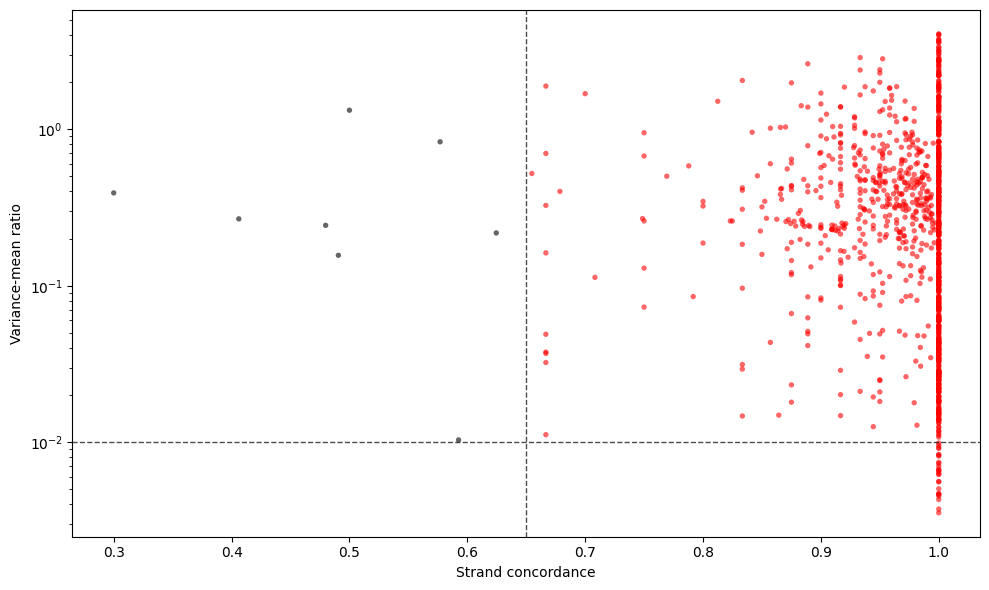

Points with strand_concordance > 0.65: 1075
Points with strand_concordance <= 0.65: 8


In [50]:
import matplotlib.pyplot as plt
import numpy as np

# Access the variant_summary DataFrame
variant_summary = mgatk.uns['variant_summary']

# Create the scatter plot
fig, ax = plt.subplots(figsize=(10, 6))

# Color points based on strand concordance threshold
threshold = 0.65
colors = ['red' if sc > threshold else 'black' 
          for sc in variant_summary['strand_concordance']]

ax.scatter(variant_summary['strand_concordance'], 
           variant_summary['vmr'], 
           c=colors, alpha=0.6, s=15, edgecolors='none')

# Set y-axis to log scale
ax.set_yscale('log')

# Add dashed threshold lines
ax.axvline(x=threshold, color='black', linestyle='--', linewidth=1, alpha=0.7)
ax.axhline(y=0.01, color='black', linestyle='--', linewidth=1, alpha=0.7)

# Labels and styling
ax.set_xlabel('Strand concordance')
ax.set_ylabel('Variance-mean ratio')

plt.tight_layout()
plt.show()

# Print summary to understand the distribution
print(f"Points with strand_concordance > {threshold}: {sum(variant_summary['strand_concordance'] > threshold)}")
print(f"Points with strand_concordance <= {threshold}: {sum(variant_summary['strand_concordance'] <= threshold)}")

In [82]:
#no of cells with 1 or more high quality vairant 
(mgatk.obs['total_confident_variants'] >= 1).sum()

1058

In [ ]:

# get the coverage array
coverage_matrix = mgatk.obsm['variant_coverage']
mean_coverage_per_cell = np.mean(coverage_matrix, axis=1)
# Define the threshold
target_threshold = 10
#Calculate the number of cells > 10 using NumPy boolean indexing
number_of_cells = np.sum(mean_coverage_per_cell > target_threshold)
print(f"Number of cells with Mean Coverage > {target_threshold}: {number_of_cells}")

Number of cells with Mean Coverage > 10: 493


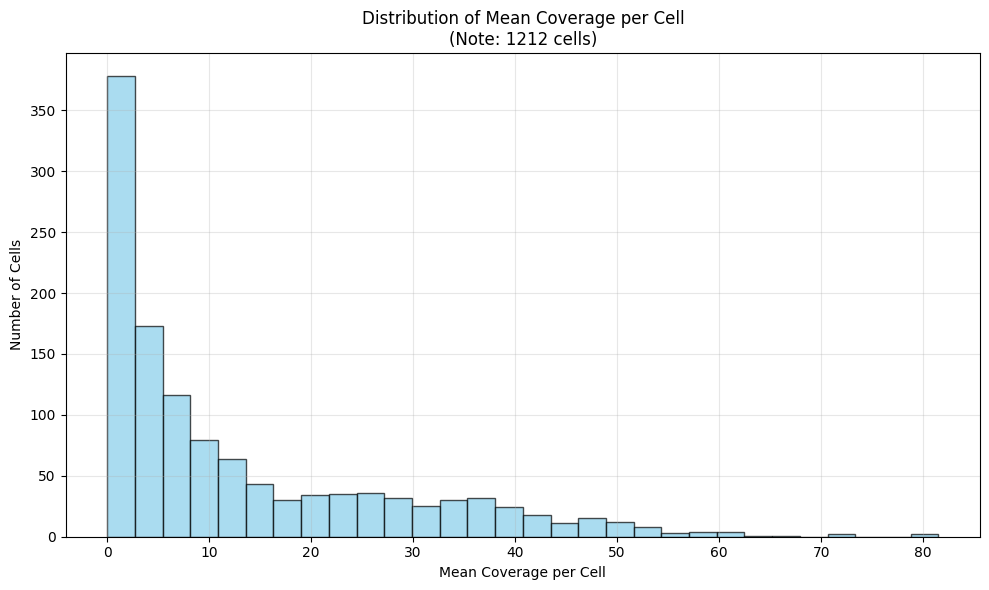

In [89]:
import matplotlib.pyplot as plt
import numpy as np

# Get coverage data from the correct location
coverage_matrix = mgatk.obsm['variant_coverage']
mean_coverage_per_cell = np.mean(coverage_matrix, axis=1)

# Create the distribution plot
plt.figure(figsize=(10, 6))
plt.hist(mean_coverage_per_cell, bins=30, alpha=0.7, edgecolor='black', color='skyblue')

plt.xlabel('Mean Coverage per Cell')
plt.ylabel('Number of Cells')
plt.title(f'Distribution of Mean Coverage per Cell\n(Note: {len(mean_coverage_per_cell)} cells)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

/tmp/ipykernel_1903281/411733312.py:6: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



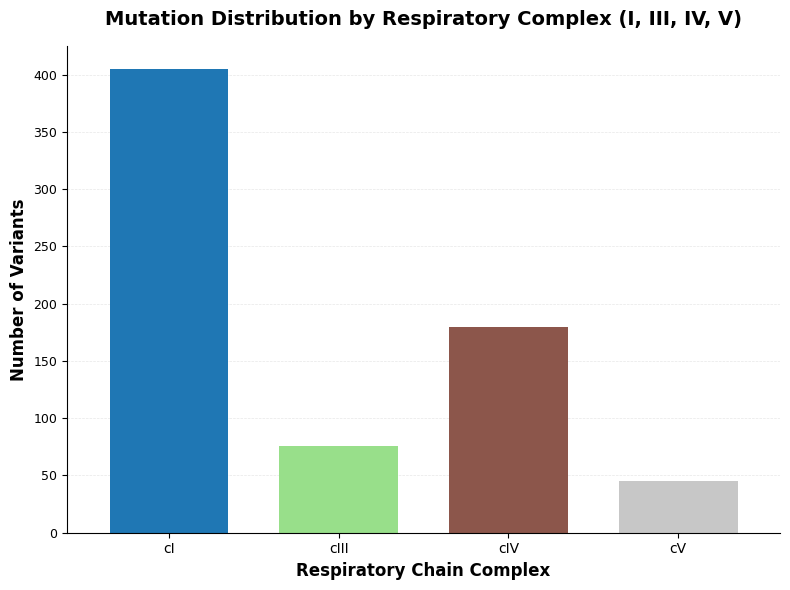


=== Summary ===
Total variants: 1083
Variants in respiratory complexes: 706
Variants in protein-coding genes: 996
Variants in D-loop/non-coding: 87


In [60]:
import matplotlib.pyplot as plt
import numpy as np

# Generate nice colors
def generate_colors(n):
    cmap = plt.cm.get_cmap('tab20')
    if n > 20:
        cmap = plt.cm.get_cmap('hsv')
    return [cmap(i/n) for i in range(n)]

# ===== Plot 1: Variants by Respiratory Complex =====
# Filter only variants in OXPHOS complex genes (I, III, IV, V)
df_resp = variant_summary[variant_summary['complex'] != 'Other'].copy()

if df_resp.empty:
    print("⚠️ No variants affecting respiratory complex proteins in filtered data.")
else:
    # Standardize complex naming
    complex_mapping = {
        'Complex I': 'cI', 
        'Complex III': 'cIII', 
        'Complex IV': 'cIV', 
        'Complex V': 'cV'
    }
    df_resp['complex_clean'] = df_resp['complex'].map(complex_mapping)
    
    # Count variants per complex
    complex_counts = df_resp['complex_clean'].value_counts()
    
    # Ensure order and only relevant complexes
    relevant_complexes = ['cI', 'cIII', 'cIV', 'cV']
    complex_counts = complex_counts.reindex(relevant_complexes, fill_value=0)
    
    # Plot
    fig, ax = plt.subplots(figsize=(8, 6))
    
    colors_complex = generate_colors(len(complex_counts))
    
    complex_counts.plot(
        kind='bar',
        ax=ax,
        width=0.7,
        color=colors_complex,
        edgecolor='none'
    )
    
    ax.set_title(
        'Mutation Distribution by Respiratory Complex (I, III, IV, V)',
        fontsize=14,
        fontweight='bold',
        pad=15
    )
    ax.set_xlabel('Respiratory Chain Complex', fontsize=12, fontweight='bold')
    ax.set_ylabel('Number of Variants', fontsize=12, fontweight='bold')
    
    plt.xticks(rotation=0, fontsize=10)
    plt.yticks(fontsize=9)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.yaxis.grid(True, linestyle='--', alpha=0.3, linewidth=0.5)
    ax.set_axisbelow(True)
    
    plt.tight_layout()
    plt.show()

# ===== Summary Statistics =====
print("\n=== Summary ===")
print(f"Total variants: {len(variant_summary)}")
print(f"Variants in respiratory complexes: {len(df_resp)}")
print(f"Variants in protein-coding genes: {len(variant_summary[variant_summary['gene'] != 'D-loop/Non-coding'])}")
print(f"Variants in D-loop/non-coding: {len(variant_summary[variant_summary['gene'] == 'D-loop/Non-coding'])}")

/tmp/ipykernel_1903281/2477924485.py:6: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.

/tmp/ipykernel_1903281/2477924485.py:8: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



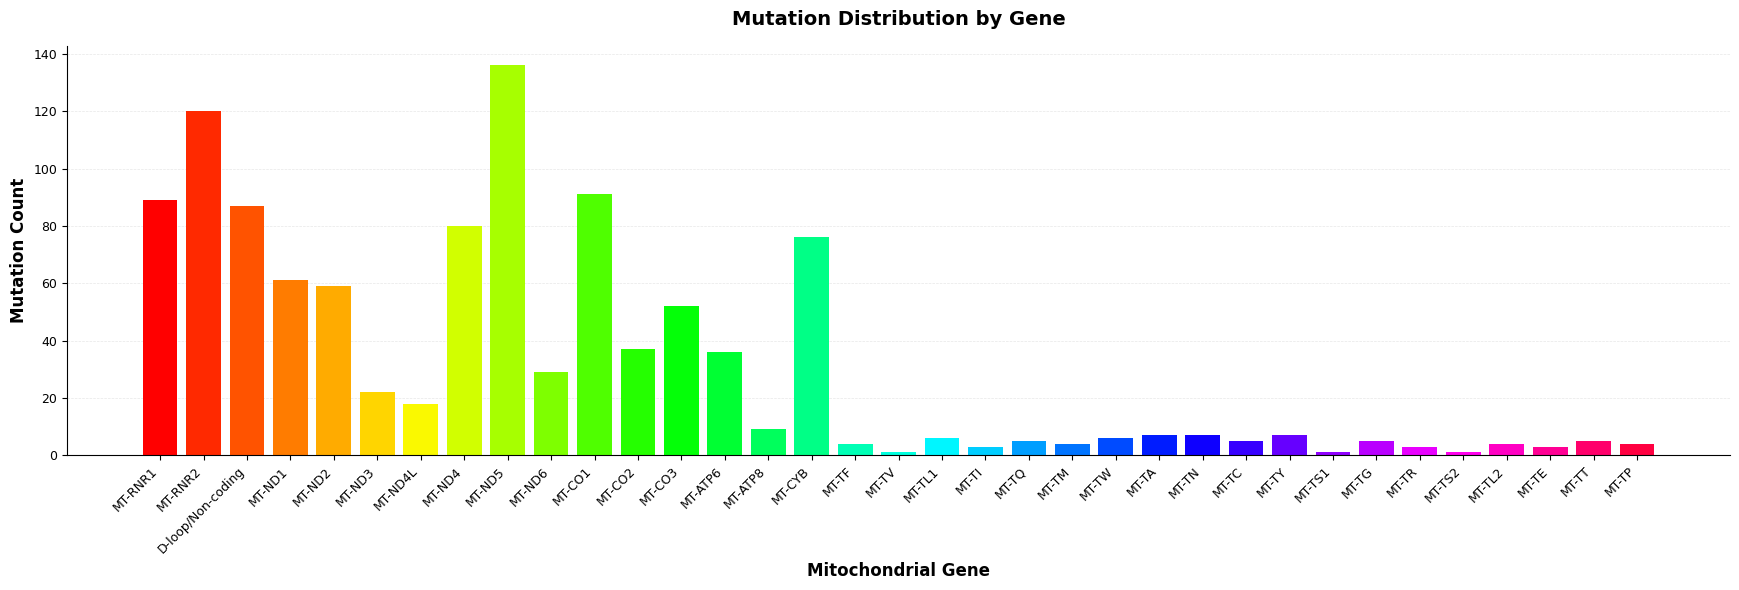


Total genes with variants: 35

Genes in order with counts:
MT-RNR1: 89
MT-RNR2: 120
D-loop/Non-coding: 87
MT-ND1: 61
MT-ND2: 59
MT-ND3: 22
MT-ND4L: 18
MT-ND4: 80
MT-ND5: 136
MT-ND6: 29
MT-CO1: 91
MT-CO2: 37
MT-CO3: 52
MT-ATP6: 36
MT-ATP8: 9
MT-CYB: 76
MT-TF: 4
MT-TV: 1
MT-TL1: 6
MT-TI: 3
MT-TQ: 5
MT-TM: 4
MT-TW: 6
MT-TA: 7
MT-TN: 7
MT-TC: 5
MT-TY: 7
MT-TS1: 1
MT-TG: 5
MT-TR: 3
MT-TS2: 1
MT-TL2: 4
MT-TE: 3
MT-TT: 5
MT-TP: 4


In [62]:
import matplotlib.pyplot as plt
import numpy as np

# Generate nice colors
def generate_colors(n):
    cmap = plt.cm.get_cmap('tab20')
    if n > 20:
        cmap = plt.cm.get_cmap('hsv')
    return [cmap(i/n) for i in range(n)]

# Define gene order matching the genomic position (5' to 3')
gene_order = [
    'MT-RNR1', 'MT-RNR2',  # rRNA genes
    'D-loop/Non-coding',  # D-loop
    'MT-ND1', 'MT-ND2', 'MT-ND3', 'MT-ND4L', 'MT-ND4', 'MT-ND5', 'MT-ND6',  # Complex I
    'MT-CO1', 'MT-CO2', 'MT-CO3',  # Complex IV
    'MT-ATP6', 'MT-ATP8',  # Complex V
    'MT-CYB',  # Complex III
    'MT-TF', 'MT-TV', 'MT-TL1', 'MT-TI', 'MT-TQ', 'MT-TM', 'MT-TW', 'MT-TA', 'MT-TN', 
    'MT-TC', 'MT-TY', 'MT-TS1', 'MT-TK', 'MT-TG', 'MT-TR', 'MT-TH', 'MT-TS2', 'MT-TL2', 
    'MT-TE', 'MT-TT', 'MT-TP'
]

# Get counts for genes that exist in your data
gene_counts_dict = variant_summary['gene'].value_counts().to_dict()

# Create ordered lists only for genes present in your data
genes_present = []
counts_present = []

for gene in gene_order:
    if gene in gene_counts_dict:
        genes_present.append(gene)
        counts_present.append(gene_counts_dict[gene])

# Create the plot
fig, ax = plt.subplots(figsize=(max(16, len(genes_present) * 0.5), 6))

# Get colors - one per gene
colors = generate_colors(len(genes_present))

# Create bar plot
ax.bar(range(len(genes_present)), counts_present, width=0.8, color=colors, edgecolor='none')

# Set x-axis labels
ax.set_xticks(range(len(genes_present)))
ax.set_xticklabels(genes_present, rotation=45, ha='right', fontsize=9)

# Styling
ax.set_title('Mutation Distribution by Gene', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Mitochondrial Gene', fontsize=12, fontweight='bold')
ax.set_ylabel('Mutation Count', fontsize=12, fontweight='bold')

plt.yticks(fontsize=9)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Light grid on y-axis only
ax.yaxis.grid(True, linestyle='--', alpha=0.3, linewidth=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

# Print summary
print(f"\nTotal genes with variants: {len(genes_present)}")
print(f"\nGenes in order with counts:")
for gene, count in zip(genes_present, counts_present):
    print(f"{gene}: {count}")

/tmp/ipykernel_1903281/1167979901.py:6: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.

/tmp/ipykernel_1903281/1167979901.py:8: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



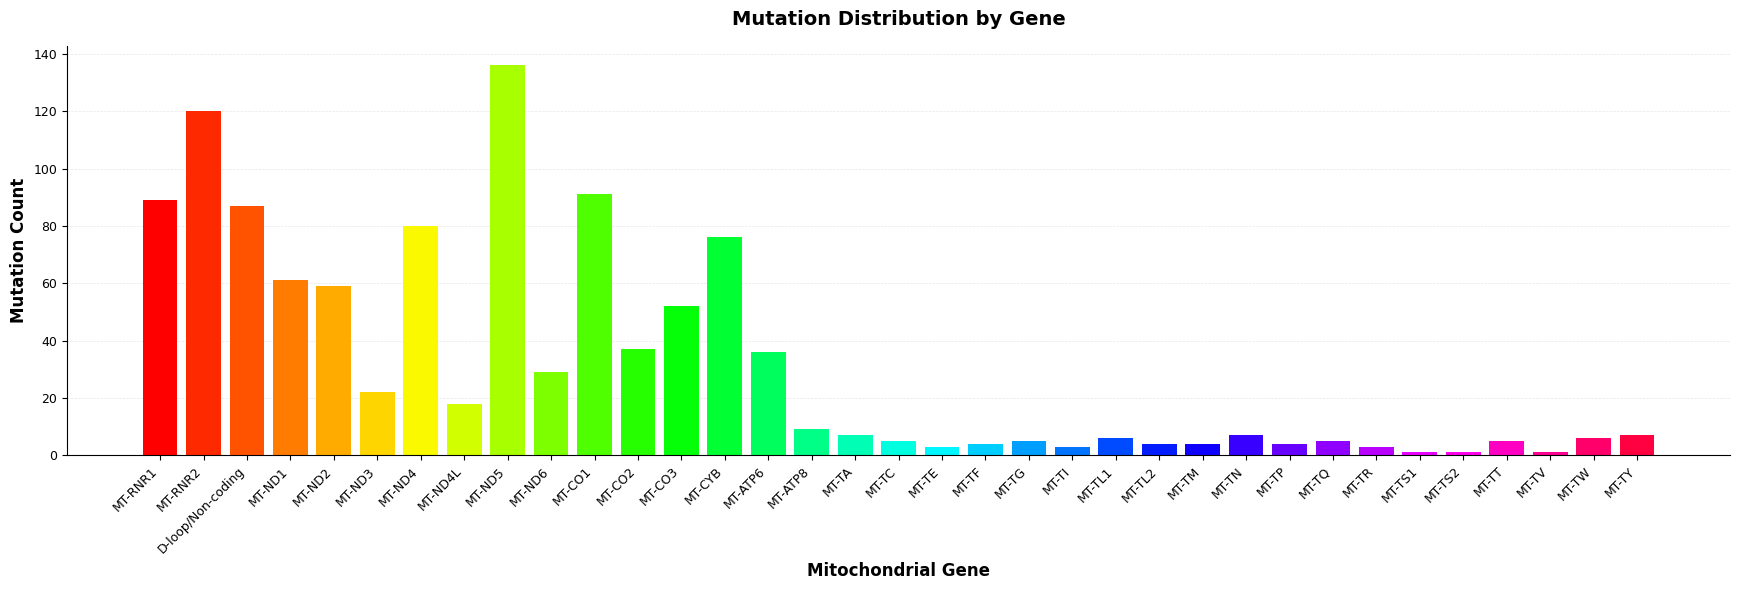


Total genes with variants: 35

Genes with counts:
MT-RNR1: 89
MT-RNR2: 120
D-loop/Non-coding: 87
MT-ND1: 61
MT-ND2: 59
MT-ND3: 22
MT-ND4: 80
MT-ND4L: 18
MT-ND5: 136
MT-ND6: 29
MT-CO1: 91
MT-CO2: 37
MT-CO3: 52
MT-CYB: 76
MT-ATP6: 36
MT-ATP8: 9
MT-TA: 7
MT-TC: 5
MT-TE: 3
MT-TF: 4
MT-TG: 5
MT-TI: 3
MT-TL1: 6
MT-TL2: 4
MT-TM: 4
MT-TN: 7
MT-TP: 4
MT-TQ: 5
MT-TR: 3
MT-TS1: 1
MT-TS2: 1
MT-TT: 5
MT-TV: 1
MT-TW: 6
MT-TY: 7


In [59]:
import matplotlib.pyplot as plt
import numpy as np

# Generate nice colors
def generate_colors(n):
    cmap = plt.cm.get_cmap('tab20')
    if n > 20:
        cmap = plt.cm.get_cmap('hsv')
    return [cmap(i/n) for i in range(n)]

# Define gene order matching the template image
gene_order = [
    'MT-RNR1', 'MT-RNR2', 'MT-D-LOOP', 'MT-DLOOP', 'D-loop/Non-coding',  # rRNA and D-loop
    'MT-ND1', 'MT-ND2', 'MT-ND3', 'MT-ND4', 'MT-ND4L', 'MT-ND5', 'MT-ND6',  # Complex I
    'MT-CO1', 'MT-CO2', 'MT-CO3',  # Complex IV (Cytochrome c oxidase)
    'MT-CYB',  # Complex III (Cytochrome b)
    'MT-ATP6', 'MT-ATP8',  # Complex V (ATP synthase)
    'MT-TA', 'MT-TC', 'MT-TD', 'MT-TE', 'MT-TF', 'MT-TG', 'MT-TH', 'MT-TI',  # tRNAs
    'MT-TK', 'MT-TL1', 'MT-TL2', 'MT-TM', 'MT-TN', 'MT-TP', 'MT-TQ', 'MT-TR',
    'MT-TS1', 'MT-TS2', 'MT-TT', 'MT-TV', 'MT-TW', 'MT-TY'
]

# Count variants per gene
gene_counts_dict = variant_summary['gene'].value_counts().to_dict()

# Create ordered counts
gene_counts_ordered = []
genes_present = []

for gene in gene_order:
    if gene in gene_counts_dict and gene_counts_dict[gene] > 0:
        genes_present.append(gene)
        gene_counts_ordered.append(gene_counts_dict[gene])

# Create the plot
fig, ax = plt.subplots(figsize=(max(16, len(genes_present) * 0.5), 6))

# Get colors - one per gene
colors = generate_colors(len(genes_present))

# Create bar plot
ax.bar(range(len(genes_present)), gene_counts_ordered, width=0.8, color=colors, edgecolor='none')

# Set x-axis labels
ax.set_xticks(range(len(genes_present)))
ax.set_xticklabels(genes_present, rotation=45, ha='right', fontsize=9)

# Styling
ax.set_title('Mutation Distribution by Gene', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Mitochondrial Gene', fontsize=12, fontweight='bold')
ax.set_ylabel('Mutation Count', fontsize=12, fontweight='bold')

plt.yticks(fontsize=9)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Light grid on y-axis only
ax.yaxis.grid(True, linestyle='--', alpha=0.3, linewidth=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

# Print summary
print(f"\nTotal genes with variants: {len(genes_present)}")
print(f"\nGenes with counts:")
for gene, count in zip(genes_present, gene_counts_ordered):
    print(f"{gene}: {count}")

Plotting first 5 confident variants out of 1083 total confident variants
Processing variant 1: Index 0, Name: A-10500-G
No confident non-zero calls for variant A-10500-G
Processing variant 2: Index 1, Name: A-10925-T


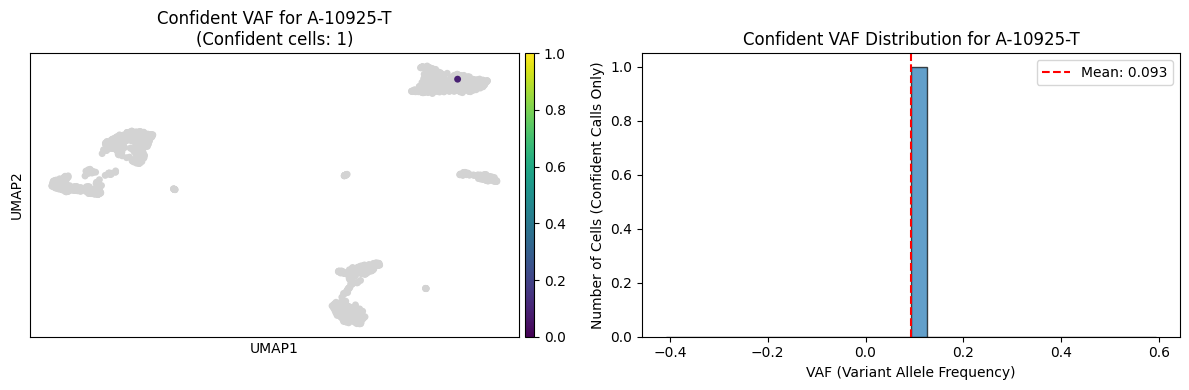

Variant A-10925-T (Index 1):
  Confident cells detected: 1
  Mean coverage: 13.2
  Total cells: 1212
  Confident calls: [False False False ... False False False]
  Confident non-zero calls: 1
  Mean confident VAF: 0.093
  Confident VAF range: 0.093 - 0.093
---
Processing variant 3: Index 2, Name: A-11719-G


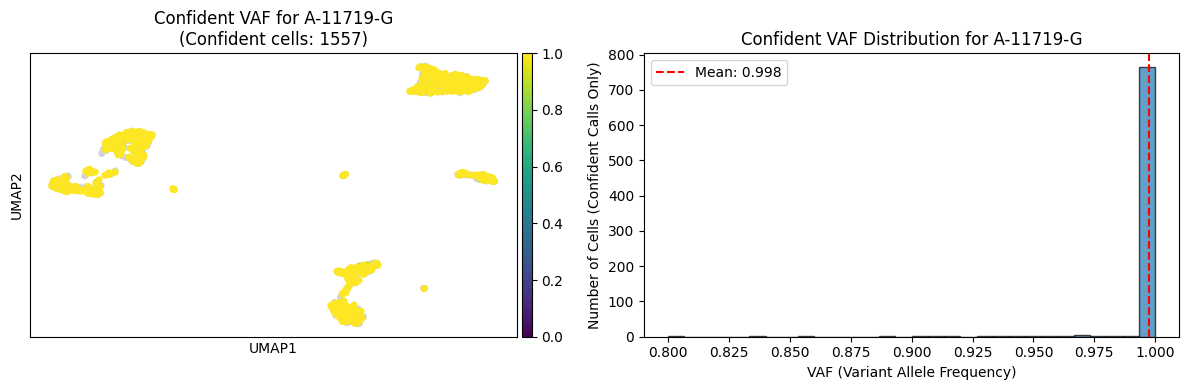

Variant A-11719-G (Index 2):
  Confident cells detected: 1557
  Mean coverage: 14.3
  Total cells: 1212
  Confident calls: [ True False False ... False False  True]
  Confident non-zero calls: 799
  Mean confident VAF: 0.998
  Confident VAF range: 0.800 - 1.000
---
Processing variant 4: Index 3, Name: A-11802-T
No confident non-zero calls for variant A-11802-T
Processing variant 5: Index 4, Name: A-11838-T


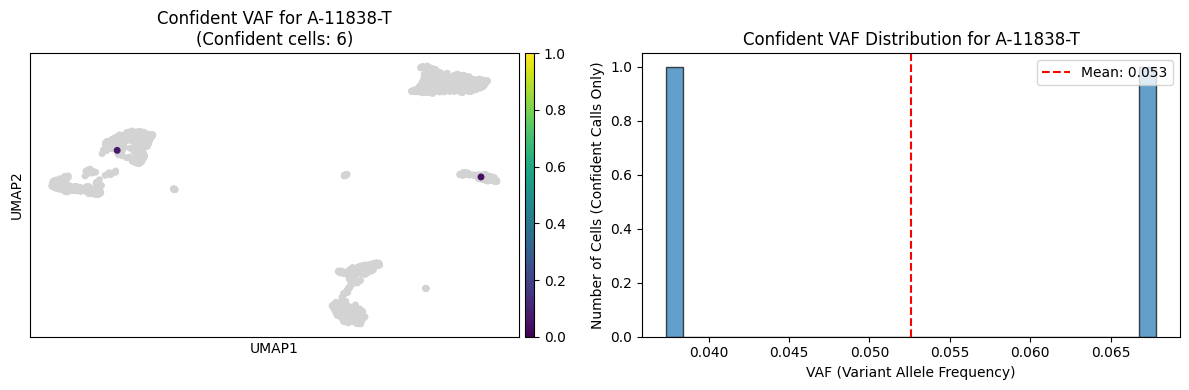

Variant A-11838-T (Index 4):
  Confident cells detected: 6
  Mean coverage: 17.2
  Total cells: 1212
  Confident calls: [False False False ... False False False]
  Confident non-zero calls: 2
  Mean confident VAF: 0.053
  Confident VAF range: 0.037 - 0.068
---


In [68]:
# Plot confident variants with UMAP and VAF distribution
import matplotlib.pyplot as plt
import numpy as np

# Get confident variants (those with at least one cell having confident detection)
confident_variants = mgatk.uns['variant_summary'][mgatk.uns['variant_summary']['n_cells_conf_detected'] > 0]

print(f"Plotting first 5 confident variants out of {len(confident_variants)} total confident variants")

# Get the variant names list
variant_names = mgatk.uns['variant_names']

for i, variant_idx in enumerate(confident_variants.index[:5]):  # Plot top 5 confident variants
    # variant_idx is already the integer index we need
    variant_name = variant_names[variant_idx]  # Get the actual variant name string
    
    print(f"Processing variant {i+1}: Index {variant_idx}, Name: {variant_name}")
    
    # Get VAF and confident matrices
    vaf_matrix = mgatk.obsm['variant_vaf']
    confident_matrix = mgatk.obsm['variant_confident']
    
    # Extract VAF and confidence for this specific variant using the integer index
    vaf_values = vaf_matrix[:, variant_idx]
    confident_calls = confident_matrix[:, variant_idx]
    
    # Filter for confident calls AND non-zero VAF
    confident_and_nonzero_mask = confident_calls & (vaf_values > 0)
    
    if not confident_and_nonzero_mask.any():
        print(f"No confident non-zero calls for variant {variant_name}")
        continue
    
    # Get filtered VAF values
    filtered_vaf_values = vaf_values[confident_and_nonzero_mask]
    
    # Create a temporary column for plotting (confident calls only)
    temp_vaf_col = np.zeros(len(mgatk.obs))
    temp_vaf_col[confident_and_nonzero_mask] = filtered_vaf_values
    # Set non-confident or zero calls to NaN for proper plotting
    temp_vaf_col[~confident_and_nonzero_mask] = np.nan
    
    # Add temporary column to obs for plotting
    mgatk.obs[f'temp_vaf_{variant_idx}'] = temp_vaf_col
    
    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # UMAP plot (only confident calls will be colored)
    sc.pl.umap(mgatk, color=f'temp_vaf_{variant_idx}', cmap="viridis", vmin=0, vmax=1, 
               title=f"Confident VAF for {variant_name}\n(Confident cells: {confident_variants.loc[variant_idx, 'n_cells_conf_detected']})", 
               ax=ax1, show=False, na_color='lightgray')
    
    # Histogram of confident VAF values only
    ax2.hist(filtered_vaf_values, bins=30, alpha=0.7, edgecolor='black')
    ax2.set_xlabel('VAF (Variant Allele Frequency)')
    ax2.set_ylabel('Number of Cells (Confident Calls Only)')
    ax2.set_title(f'Confident VAF Distribution for {variant_name}')
    ax2.axvline(filtered_vaf_values.mean(), color='red', linestyle='--', 
                label=f'Mean: {filtered_vaf_values.mean():.3f}')
    ax2.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    total_cells = len(mgatk.obs)
    confident_cells = confident_calls.sum()
    confident_nonzero_cells = len(filtered_vaf_values)
    
    print(f"Variant {variant_name} (Index {variant_idx}):")
    print(f"  Confident cells detected: {confident_variants.loc[variant_idx, 'n_cells_conf_detected']}")
    print(f"  Mean coverage: {confident_variants.loc[variant_idx, 'mean_coverage']:.1f}")
    print(f"  Total cells: {total_cells}")
    print(f"  Confident calls: {confident_calls}")
    print(f"  Confident non-zero calls: {confident_nonzero_cells}")
    print(f"  Mean confident VAF: {filtered_vaf_values.mean():.3f}")
    print(f"  Confident VAF range: {filtered_vaf_values.min():.3f} - {filtered_vaf_values.max():.3f}")
    print("---")
    
    # Clean up temporary column
    mgatk.obs.drop(columns=[f'temp_vaf_{variant_idx}'], inplace=True)

In [ ]:
#save mgatk object 
/mnt/claw-raid/elliot/mgatk_analysis.h5ad

Found 3 enriched variants
   idx       name  in_target  in_other  enrichment
0  264   C-6832-T          4         0         4.0
2  905  G-13676-A          2         0         2.0
1  677  C-16086-T          3         1         1.5


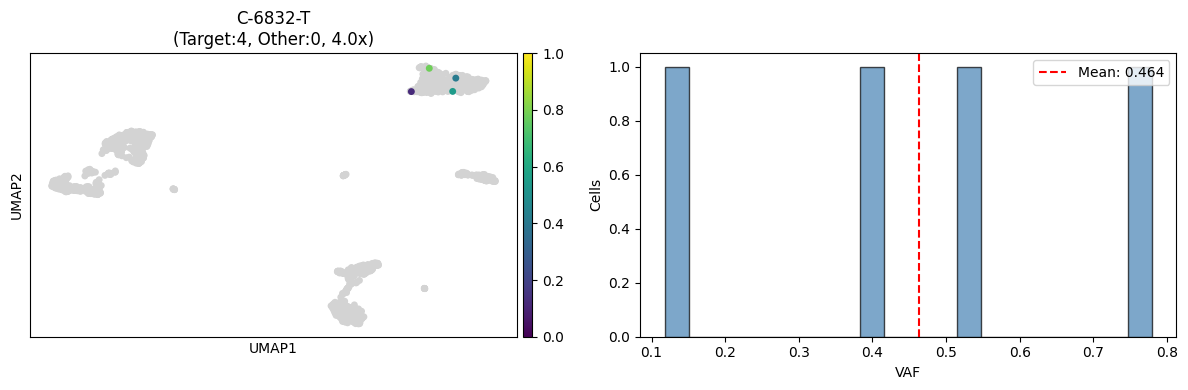

In [80]:
# Find cluster-enriched variants
TARGET_CLUSTERS = ['0']
MIN_CELLS_IN_TARGET = 2
MAX_CELLS_IN_OTHER = 3
MIN_ENRICHMENT = 1.5

import numpy as np
import pandas as pd

_mask = np.isin(mgatk.obs['leiden'].values, TARGET_CLUSTERS)
_enriched = []

for _i in range(len(mgatk.uns['variant_names'])):
    _vaf = mgatk.obsm['variant_vaf'][:, _i]
    _conf = mgatk.obsm['variant_confident'][:, _i]
    _in_target = (_conf & _mask & (_vaf > 0)).sum()
    _in_other = (_conf & ~_mask & (_vaf > 0)).sum()
    _enrich = _in_target / (_in_other + 1)
    
    if _in_target >= MIN_CELLS_IN_TARGET and _in_other <= MAX_CELLS_IN_OTHER and _enrich >= MIN_ENRICHMENT:
        _enriched.append({'idx': _i, 'name': mgatk.uns['variant_names'][_i], 
                         'in_target': _in_target, 'in_other': _in_other, 'enrichment': _enrich})

enriched_df = pd.DataFrame(_enriched).sort_values('enrichment', ascending=False)
print(f"Found {len(enriched_df)} enriched variants")
print(enriched_df)

VARIANT_TO_PLOT = 0

import matplotlib.pyplot as plt
import scanpy as sc

_r = enriched_df.iloc[VARIANT_TO_PLOT]
_m = mgatk.obsm['variant_confident'][:, _r['idx']] & np.isin(mgatk.obs['leiden'].values, TARGET_CLUSTERS) & (mgatk.obsm['variant_vaf'][:, _r['idx']] > 0)
mgatk.obs['_tmp'] = np.where(_m, mgatk.obsm['variant_vaf'][:, _r['idx']], np.nan)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
sc.pl.umap(mgatk, color='_tmp', cmap="viridis", vmin=0, vmax=1,
           title=f"{_r['name']}\n(Target:{int(_r['in_target'])}, Other:{int(_r['in_other'])}, {_r['enrichment']:.1f}x)",
           ax=ax1, show=False, na_color='lightgray')
ax2.hist(mgatk.obs.loc[_m, '_tmp'].dropna(), bins=20, alpha=0.7, edgecolor='black', color='steelblue')
ax2.set_xlabel('VAF')
ax2.set_ylabel('Cells')
ax2.axvline(mgatk.obs.loc[_m, '_tmp'].mean(), color='red', linestyle='--', label=f'Mean: {mgatk.obs.loc[_m, "_tmp"].mean():.3f}')
ax2.legend()
plt.tight_layout()
plt.show()
mgatk.obs.drop(columns=['_tmp'], inplace=True)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Convert to dense array if sparse
coverage_matrix = mgatk.X
if hasattr(coverage_matrix, 'toarray'):
    coverage_matrix = coverage_matrix.toarray()

print(f"Coverage matrix shape: {coverage_matrix.shape}")

# Get cell names
cell_names = mgatk.obs_names

# Create the plot
plt.figure(figsize=(15, 10))

# Plot each cell as a line
for i, cell_name in enumerate(cell_names):
    coverage = coverage_matrix[i, :]
    # Ensure both x and y have same dimensions
    x_positions = range(len(coverage))
    plt.plot(x_positions, coverage, alpha=0.7, linewidth=1, label=cell_name)

plt.xlabel('Position on Mitochondrial Genome')
plt.ylabel('Read Depth')
plt.title('Mitochondrial Genome Coverage for All Cells')
plt.grid(True, alpha=0.3)

# Only show legend if there aren't too many cells
if len(cell_names) <= 20:
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

Coverage matrix shape: (1475, 6062095)


KeyboardInterrupt: 

Variant A-10500-G: Insufficient data points (0)
Variant A-10925-T: Insufficient data points (1)


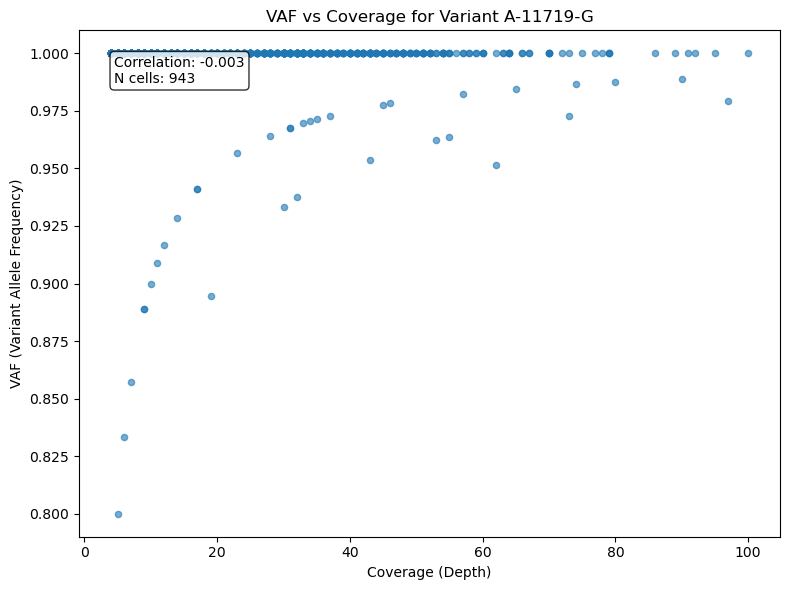

Variant A-11719-G:
  Coverage range: 4.0 - 100.0
  Mean coverage: 21.9
  VAF range: 0.800 - 1.000
  Correlation (VAF vs Coverage): -0.003
---
Variant A-11802-T: Insufficient data points (0)
Variant A-11838-T: Insufficient data points (3)
Variant A-15170-G: Insufficient data points (2)


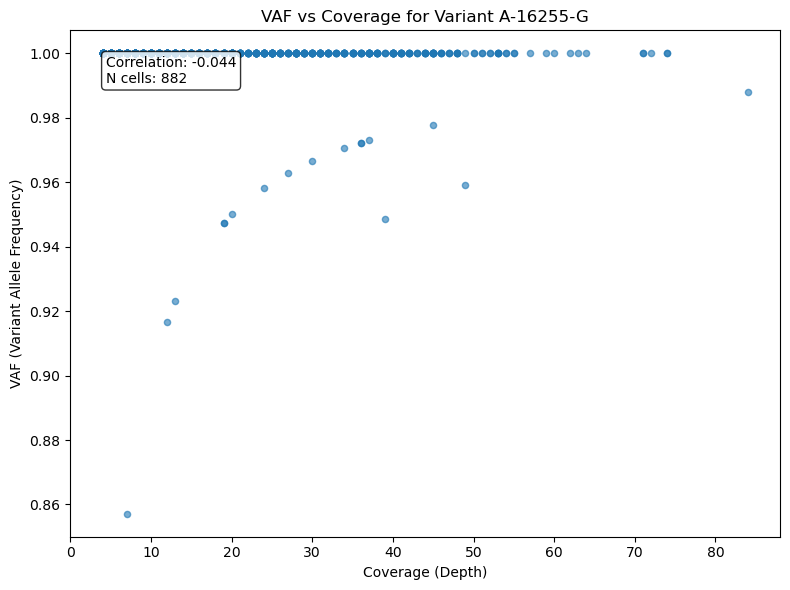

Variant A-16255-G:
  Coverage range: 4.0 - 84.0
  Mean coverage: 18.4
  VAF range: 0.857 - 1.000
  Correlation (VAF vs Coverage): -0.044
---


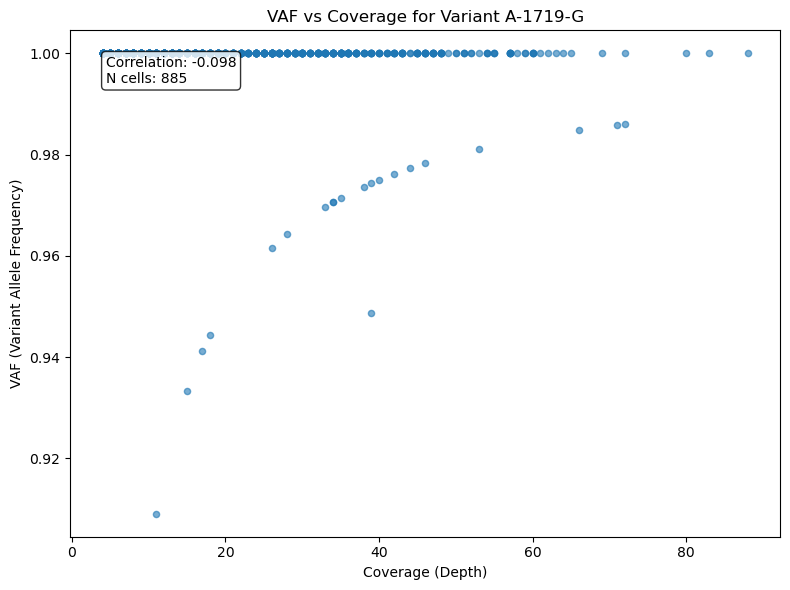

Variant A-1719-G:
  Coverage range: 4.0 - 88.0
  Mean coverage: 19.7
  VAF range: 0.909 - 1.000
  Correlation (VAF vs Coverage): -0.098
---
Variant A-1770-G: Insufficient data points (1)


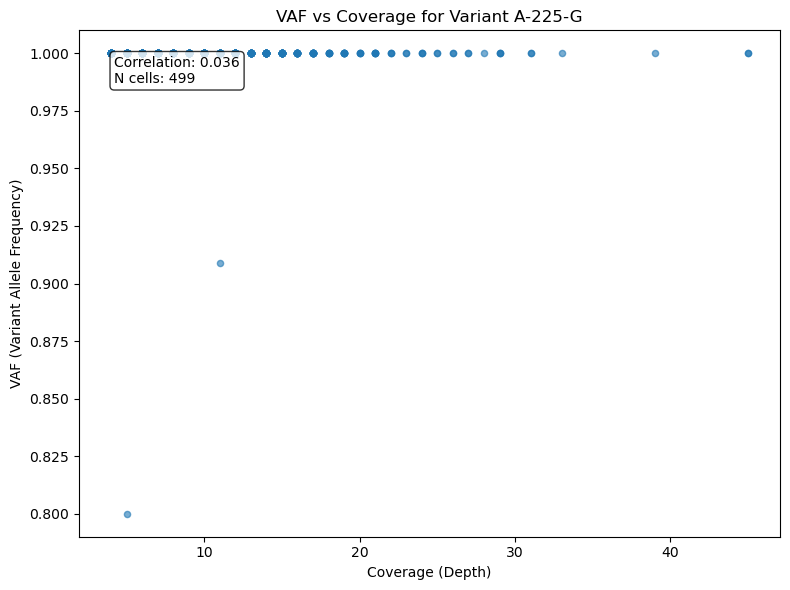

Variant A-225-G:
  Coverage range: 4.0 - 45.0
  Mean coverage: 10.5
  VAF range: 0.800 - 1.000
  Correlation (VAF vs Coverage): 0.036
---
Variant A-2573-G: Insufficient data points (0)
Variant A-2620-g: Insufficient data points (0)
Variant A-4148-G: Insufficient data points (1)
Variant A-5585-G: Insufficient data points (2)
Variant A-64-C: Insufficient data points (0)
Variant A-8206-G: Insufficient data points (0)
Variant A-822-G: Insufficient data points (1)
Variant A-9342-G: Insufficient data points (0)
Variant C-11485-T: Insufficient data points (1)
Variant C-11684-T: Insufficient data points (1)
Variant C-12758-T: Insufficient data points (1)
Variant C-13006-T: Insufficient data points (1)
Variant C-13039-T: Insufficient data points (0)
Variant C-13163-T: Insufficient data points (1)
Variant C-13830-T: Insufficient data points (1)


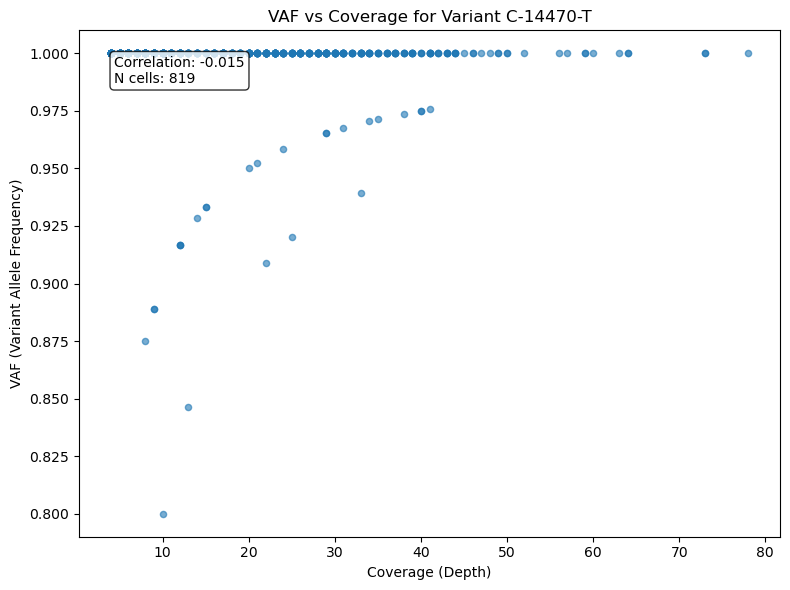

Variant C-14470-T:
  Coverage range: 4.0 - 78.0
  Mean coverage: 16.1
  VAF range: 0.800 - 1.000
  Correlation (VAF vs Coverage): -0.015
---
Variant C-15306-T: Insufficient data points (1)
Variant C-15784-T: Insufficient data points (1)


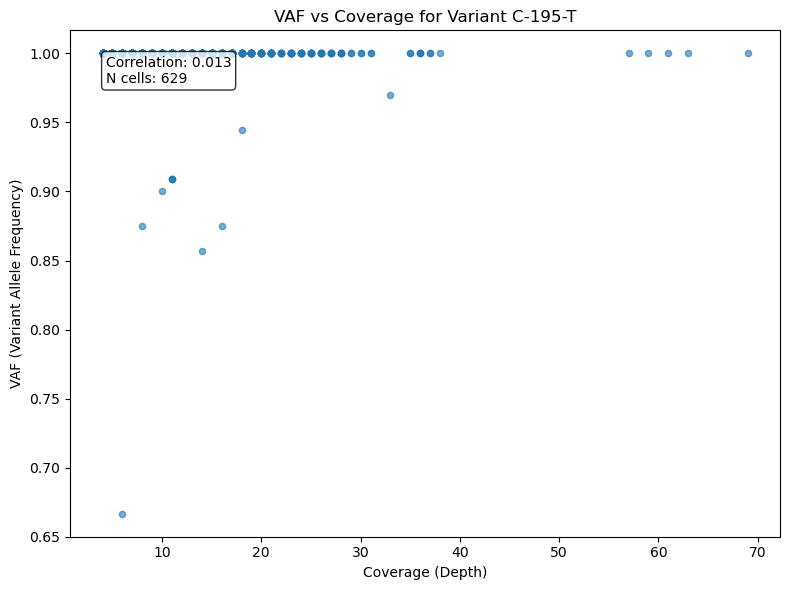

Variant C-195-T:
  Coverage range: 4.0 - 69.0
  Mean coverage: 12.0
  VAF range: 0.667 - 1.000
  Correlation (VAF vs Coverage): 0.013
---
Variant C-3264-t: Insufficient data points (0)


In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Get the matrices and variant info
vaf_matrix = mgatk.obsm['variant_vaf']        # cells x variants
coverage_matrix = mgatk.obsm['variant_coverage']  # cells x variants  
variant_names = mgatk.uns['variant_names']

# For variants in your confident_variants
for i, variant_idx in enumerate(confident_variants.index[:30]):  # Plot top 5 confident variants
    # variant_idx is already the integer index we need
    variant_name = variant_names[variant_idx]  # Get the actual variant name string
    try:
        variant_idx = confident_variants.index[i]  # Get the actual variant index
        # Find the index of this variant in the variant_names list
        variant_idx = variant_names.index(variant_name)
        
        # Get VAF and coverage values for this variant across all cells
        vaf_values = vaf_matrix[:, variant_idx]
        coverage_values = coverage_matrix[:, variant_idx]
        
        # Filter for cells with non-zero VAF and valid coverage
        mask = (vaf_values > 0) & (coverage_values > 0)
        
        if mask.sum() > 5:  # Need at least 5 points for meaningful plot
            filtered_vaf = vaf_values[mask]
            filtered_coverage = coverage_values[mask]
            
            # Create scatter plot
            fig, ax = plt.subplots(1, 1, figsize=(8, 6))
            
            scatter = ax.scatter(filtered_coverage, filtered_vaf, alpha=0.6, s=20)
            ax.set_xlabel('Coverage (Depth)')
            ax.set_ylabel('VAF (Variant Allele Frequency)')
            ax.set_title(f'VAF vs Coverage for Variant {variant_name}')
            
            # Add statistics
            if len(filtered_coverage) > 1 and len(set(filtered_coverage)) > 1:
                correlation = np.corrcoef(filtered_coverage, filtered_vaf)[0, 1]
            else:
                correlation = np.nan
                
            ax.text(0.05, 0.95, f'Correlation: {correlation:.3f}\nN cells: {len(filtered_vaf)}', 
                    transform=ax.transAxes, verticalalignment='top', 
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
            
            plt.tight_layout()
            plt.show()
            
            # Print summary
            print(f"Variant {variant_name}:")
            print(f"  Coverage range: {filtered_coverage.min():.1f} - {filtered_coverage.max():.1f}")
            print(f"  Mean coverage: {filtered_coverage.mean():.1f}")
            print(f"  VAF range: {filtered_vaf.min():.3f} - {filtered_vaf.max():.3f}")
            print(f"  Correlation (VAF vs Coverage): {correlation:.3f}")
            print("---")
        else:
            print(f"Variant {variant_name}: Insufficient data points ({mask.sum()})")
            
    except Exception as e:
        print(f"Error processing variant {variant_name}: {e}")

In [10]:
import numpy as np
import pandas as pd

# Get the matrices
vaf_matrix = mgatk.obsm['variant_vaf'].copy()  # Make a copy to modify
coverage_matrix = mgatk.obsm['variant_coverage']
confident_matrix = mgatk.obsm['variant_confident']
variant_names = mgatk.uns['variant_names']
variant_summary = mgatk.uns['variant_summary']

print(f"Original VAF matrix shape: {vaf_matrix.shape}")
print(f"Non-zero VAF values before filtering: {(vaf_matrix > 0).sum()}")

# Count variants with at least one expressing cell before filtering
variants_with_expression_before = (vaf_matrix > 0).any(axis=0).sum()
print(f"Variants with at least one expressing cell before filtering: {variants_with_expression_before}")

# Create high-quality filtered VAF matrix
high_quality_vaf_matrix = vaf_matrix.copy()
variant_names_list = []
# For each variant, apply cell-level quality filters
for i, variant_name in enumerate(variant_names):
    # Get variant-level statistics
    variant_stats = variant_summary.iloc[i]
    strand_concordance = variant_stats['strand_concordance']
    variance = variant_stats['variance'] 
    mean_coverage = variant_stats['mean_coverage']
    
    # Get cell-level data for this variant
    cell_vaf = vaf_matrix[:, i]
    cell_coverage = coverage_matrix[:, i]
    cell_confident = confident_matrix[:, i]
    
    # Define quality criteria for this variant's cells
    quality_mask = (
        (strand_concordance >= 0.5) &  # Variant-level criterion
        (mean_coverage >= 20) &        # Variant-level criterion
        (cell_vaf >= 0.1)        # Cell-level: VAF > 10%
    )
    
    # Set non-qualifying cells to 0 for this variant
    high_quality_vaf_matrix[~quality_mask, i] = 0

print(f"Non-zero VAF values after high-quality filtering: {(high_quality_vaf_matrix > 0).sum()}")
print(f"Percentage of calls retained: {(high_quality_vaf_matrix > 0).sum() / (vaf_matrix > 0).sum() * 100:.1f}%")

# Count variants with at least one expressing cell after filtering
variants_with_expression_after = (high_quality_vaf_matrix > 0).any(axis=0).sum()
print(f"Variants with at least one expressing cell after filtering: {variants_with_expression_after}")
print(f"Percentage of variants retained: {variants_with_expression_after / variants_with_expression_before * 100:.1f}%")

# Count variants completely eliminated by filtering
variants_eliminated = variants_with_expression_before - variants_with_expression_after
print(f"Variants completely eliminated by filtering: {variants_eliminated}")
print("variants left" , variants_with_expression_after)
# Store the high-quality filtered matrix
mgatk.obsm['variant_vaf_high_quality'] = high_quality_vaf_matrix

# Now you can use this filtered matrix for analysis
print("\nHigh-quality filtered VAF matrix stored in mgatk.obsm['variant_vaf_high_quality']")

Original VAF matrix shape: (1475, 1083)
Non-zero VAF values before filtering: 24046
Variants with at least one expressing cell before filtering: 694
Non-zero VAF values after high-quality filtering: 0
Percentage of calls retained: 0.0%
Variants with at least one expressing cell after filtering: 0
Percentage of variants retained: 0.0%
Variants completely eliminated by filtering: 694
variants left 0

High-quality filtered VAF matrix stored in mgatk.obsm['variant_vaf_high_quality']


In [11]:
# Boolean mask: True for variants with at least one retained (non-zero) cell
high_quality_mask = (high_quality_vaf_matrix > 0).any(axis=0)

# Get corresponding variant names
high_quality_variant_names = np.array(variant_names)[high_quality_mask]
print(high_quality_variant_names)
print(len(high_quality_variant_names))

## Flip variants to match format 
converted = [f"MT-{alt}-{pos}-{ref}" for ref, pos, alt in (v.split('-') for v in high_quality_variant_names)]
print(converted)

required_columns = ["chr", "pos", "ref", "alt"]

genebe_df = pd.DataFrame(
    [v.split('-') for v in converted],
    columns=["chr","ref", "pos", "alt"]
)
genebe_df = genebe_df[required_columns]

print(genebe_df.head())

[]
0
[]
Empty DataFrame
Columns: [chr, pos, ref, alt]
Index: []


In [12]:
import genebe as gnb
annotated_PBMC = gnb.annotate_dataframe_variants(genebe_df,use_ensembl=True,use_refseq=False, genome='hg38', flatten_consequences=False)

ModuleNotFoundError: No module named 'genebe'

In [ ]:
annotated_PBMC.to_csv('PBMC_PostMortem_genebe.csv', index=False)

In [13]:
#Gene classification 
gene_classification = {
    'MT-ND1': 'Complex I',
    'MT-ND2': 'Complex I',
    'MT-ND3': 'Complex I',
    'MT-ND4': 'Complex I',
    'MT-ND4L': 'Complex I',
    'MT-ND5': 'Complex I',
    'MT-ND6': 'Complex I',
    'MT-CO1': 'Complex IV',
    'MT-CO2': 'Complex IV',
    'MT-CO3': 'Complex IV',
    'MT-CYB': 'Complex III',
    'MT-ATP6': 'Complex V',
    'MT-ATP8': 'Complex V',
    'MT-RNR1': 'rRNA',
    'MT-RNR2': 'rRNA',
    'MT-TF': 'tRNA',  
    'MT-TV': 'tRNA',
    'MT-TI': 'tRNA',
    'MT-TL1': 'tRNA',
    'MT-TL2': 'tRNA',
    'MT-TK': 'tRNA',
    'MT-TM': 'tRNA',
    'MT-TP': 'tRNA',
    'MT-TS1': 'tRNA',
    'MT-TS2': 'tRNA',
    'MT-TW': 'tRNA',
    'MT-TA': 'tRNA',
    'MT-TC': 'tRNA',
    'MT-TY': 'tRNA',
    'MT-TH': 'tRNA',
    'MT-TG': 'tRNA',
    'MT-TR': 'tRNA',
    'MT-TN': 'tRNA',
    'MT-TD': 'tRNA',
    'MT-TE': 'tRNA',
    'MT-TQ': 'tRNA'
}

In [14]:
# Create a copy of the dataframe and add the functional classification
annotated_PBMC_classified = annotated_PBMC.copy()
annotated_PBMC_classified['gene_functional_group'] = annotated_PBMC_classified['gene_symbol'].map(gene_classification)

# Handle any genes not in the classification (mark as 'Other')
annotated_PBMC_classified['gene_functional_group'] = annotated_PBMC_classified['gene_functional_group'].fillna('Other')

# Create a 2x2 subplot layout for the pie charts
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(20, 16))  # Increased figure size

# Function to prepare data for pie chart (handle NaN values and limit categories)
def prepare_pie_data(series, max_categories=20):
    # Count values, excluding NaN
    value_counts = series.value_counts(dropna=True)
    
    # If there are more categories than max_categories, group the smallest ones as "Other"
    if len(value_counts) > max_categories:
        top_categories = value_counts.head(max_categories - 1)
        other_count = value_counts.iloc[max_categories - 1:].sum()
        
        # Create new series with "Other" category
        pie_data = top_categories.copy()
        pie_data['Other'] = other_count
    else:
        pie_data = value_counts
    
    return pie_data

# 1. Gene Functional Group pie chart (using your classification)
gene_functional_data = prepare_pie_data(annotated_PBMC_classified['gene_functional_group'])
colors1 = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#ff99cc', '#c2c2f0']  # Custom colors for complexes

# Option 1: Use pctdistance and labeldistance to control spacing
wedges1, texts1, autotexts1 = ax1.pie(gene_functional_data.values, labels=gene_functional_data.index, 
                                       autopct='%1.1f%%', startangle=90, 
                                       colors=colors1[:len(gene_functional_data)],
                                       pctdistance=0.85,    # Distance of percentage labels from center
                                       labeldistance=1.1)   # Distance of category labels from center

# Adjust text properties to prevent overlap
for autotext in autotexts1:
    autotext.set_fontsize(10)
    autotext.set_fontweight('bold')
    autotext.set_color('white')

for text in texts1:
    text.set_fontsize(11)

ax1.set_title(f'Variants by Mitochondrial Functional Group\n(Total variants: {len(annotated_PBMC)})', 
              fontsize=14, fontweight='bold', pad=20)

# 2. Effect pie chart with adjusted spacing
effect_data = prepare_pie_data(annotated_PBMC['effect'])
wedges2, texts2, autotexts2 = ax2.pie(effect_data.values, labels=effect_data.index, 
                                       autopct='%1.1f%%', startangle=90,
                                       pctdistance=0.85, labeldistance=1.1)

for autotext in autotexts2:
    autotext.set_fontsize(10)
    autotext.set_fontweight('bold')
    autotext.set_color('white')

for text in texts2:
    text.set_fontsize(11)

ax2.set_title(f'Variants by Effect\n(Total variants: {len(annotated_PBMC)})', 
              fontsize=14, fontweight='bold', pad=20)

# 3. ACMG Classification pie chart
acmg_data = prepare_pie_data(annotated_PBMC['acmg_classification'])
if len(acmg_data) > 0:
    wedges3, texts3, autotexts3 = ax3.pie(acmg_data.values, labels=acmg_data.index, 
                                           autopct='%1.1f%%', startangle=90,
                                           pctdistance=0.85, labeldistance=1.1)
    
    for autotext in autotexts3:
        autotext.set_fontsize(10)
        autotext.set_fontweight('bold')
        autotext.set_color('white')
    
    for text in texts3:
        text.set_fontsize(11)
    
    ax3.set_title(f'Variants by ACMG Classification\n(Total classified: {acmg_data.sum()})', 
                  fontsize=14, fontweight='bold', pad=20)
else:
    ax3.text(0.5, 0.5, 'No ACMG Classifications\nAvailable', ha='center', va='center', fontsize=12)
    ax3.set_title('ACMG Classification', fontsize=14, fontweight='bold', pad=20)

# 4. ClinVar Classification pie chart
clinvar_data = prepare_pie_data(annotated_PBMC['clinvar_classification'])
if len(clinvar_data) > 0:
    wedges4, texts4, autotexts4 = ax4.pie(clinvar_data.values, labels=clinvar_data.index, 
                                           autopct='%1.1f%%', startangle=90,
                                           pctdistance=0.85, labeldistance=1.1)
    
    for autotext in autotexts4:
        autotext.set_fontsize(10)
        autotext.set_fontweight('bold')
        autotext.set_color('white')
    
    for text in texts4:
        text.set_fontsize(11)
    
    ax4.set_title(f'Variants by ClinVar Classification\n(Total classified: {clinvar_data.sum()})', 
                  fontsize=14, fontweight='bold', pad=20)
else:
    ax4.text(0.5, 0.5, 'No ClinVar Classifications\nAvailable', ha='center', va='center', fontsize=12)
    ax4.set_title('ClinVar Classification', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout(pad=3.0)  # Add more padding between subplots
plt.show()

# Print summary statistics for each category
print("=== SUMMARY STATISTICS ===")
print(f"\n1. Mitochondrial Functional Group Distribution:")
functional_summary = annotated_PBMC_classified['gene_functional_group'].value_counts(dropna=True)
print(f"   Total functional groups represented: {len(functional_summary)}")
print(f"   Most common functional group: {functional_summary.index[0]} ({functional_summary.iloc[0]} variants)")
print(f"   All functional groups:")
for group, count in functional_summary.items():
    print(f"      {group}: {count} variants ({count/len(annotated_PBMC)*100:.1f}%)")

print(f"\n2. Individual Gene Symbol Distribution:")
gene_summary = annotated_PBMC['gene_symbol'].value_counts(dropna=True)
print(f"   Total genes represented: {len(gene_summary)}")
print(f"   Most common gene: {gene_summary.index[0]} ({gene_summary.iloc[0]} variants)")
print(f"   Top 10 genes:")
for i, (gene, count) in enumerate(gene_summary.head(10).items()):
    functional_group = gene_classification.get(gene, 'Other')
    print(f"      {i+1}. {gene} ({functional_group}): {count} variants ({count/len(annotated_PBMC)*100:.1f}%)")

print(f"\n3. Effect Distribution:")
effect_summary = annotated_PBMC['effect'].value_counts(dropna=True)
print(f"   Total effect types: {len(effect_summary)}")
if len(effect_summary) > 0:
    print(f"   Most common effect: {effect_summary.index[0]} ({effect_summary.iloc[0]} variants)")
    print(f"   All effects:")
    for effect, count in effect_summary.items():
        print(f"      {effect}: {count} variants ({count/len(annotated_PBMC)*100:.1f}%)")

acmg_summary = annotated_PBMC['acmg_classification'].value_counts(dropna=True)
print(f"\n4. ACMG Classification Distribution:")
print(f"   Total ACMG classified variants: {annotated_PBMC['acmg_classification'].notna().sum()}")
print(f"   Unclassified variants: {annotated_PBMC['acmg_classification'].isna().sum()}")
for classification, count in acmg_summary.items():
    print(f"      {classification}: {count} variants")

print(f"\n5. ClinVar Classification Distribution:")
clinvar_summary = annotated_PBMC['clinvar_classification'].value_counts(dropna=True)
print(f"   Total ClinVar classified variants: {annotated_PBMC['clinvar_classification'].notna().sum()}")
print(f"   Unclassified variants: {annotated_PBMC['clinvar_classification'].isna().sum()}")
if len(clinvar_summary) > 0:
    for classification, count in clinvar_summary.items():
        print(f"      {classification}: {count} variants")

NameError: name 'annotated_PBMC' is not defined

In [ ]:
## Import mitoTIP dataframe to look at tRNA variants only 
mitoTIP = pd.read_csv('/Users/lucascortes/Library/CloudStorage/OneDrive-Personal/Documents/Work/Pickett/ATAC-Seq/Usefull_Stuff/mitotip_scores.txt', sep='\t')
mitoTIP.head(20)

,Position,rCRS,Alt,MitoTIP_Score,Quartile,Count,Percentage,Mitomap_Status
0,577,G,:,20.3833,Q1,0,0.0,Absent
1,577,G,A,17.7500,Q1,0,0.0,Absent
2,577,G,C,17.7500,Q1,0,0.0,Absent
3,577,G,T,17.7500,Q1,0,0.0,Absent
4,578,T,:,18.6851,Q1,0,0.0,Absent
5,578,T,A,18.6851,Q1,0,0.0,Absent
6,578,T,C,16.6004,Q1,0,0.0,Absent
7,578,T,G,18.6851,Q1,0,0.0,Absent
8,579,T,:,17.6526,Q1,0,0.0,Absent
9,579,T,A,17.6526,Q1,0,0.0,Absent


In [ ]:
## Dataframe containing tRNA variants likely or poissbly pathogenic as per mitoTIP scoring method 
mitoTIP_filtered = mitoTIP[(mitoTIP['Quartile'] == 'Q2') | (mitoTIP['Quartile'] == 'Q1')]
mitoTIP_filtered.head(20)

Empty DataFrame
Columns: [Position, rCRS, Alt, MitoTIP_Score, Quartile, Count, Percentage, Mitomap_Status]
Index: []


Finding variants enriched in cluster(s): ['1']
Criteria:
  - Min confident cells in target: 2
  - Max confident cells in other clusters: 3
  - Min mean VAF in target: 0.01
  - Min enrichment ratio: 1.5
Cells in target cluster(s): 261
Cells in other clusters: 951

✅ Found 1 enriched variants!

Top variants:
 variant_idx variant_name  confident_in_target  confident_in_other  mean_vaf_target  enrichment
         804     C-7660-T                    2                   0             0.92         2.0

Plotting top 1 enriched variants


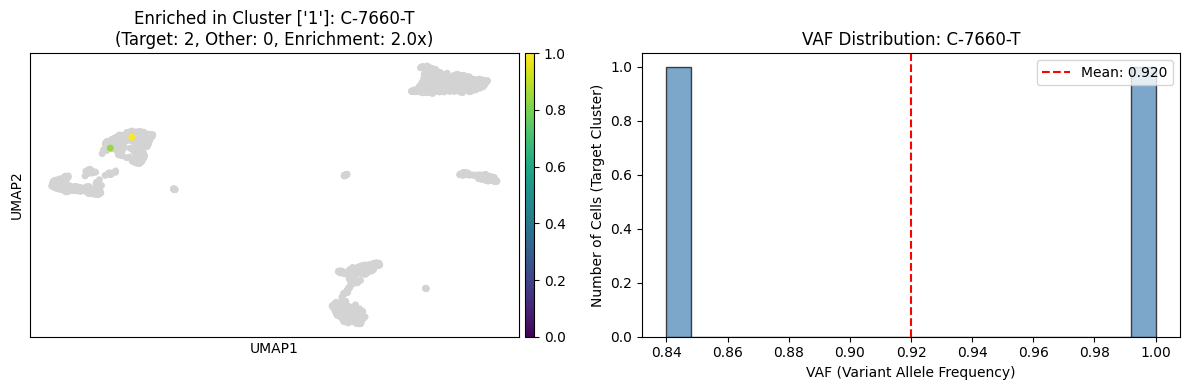


C-7660-T:
  Confident in target: 2
  Confident in other: 0
  Mean VAF in target: 0.920
  Enrichment: 2.00x

Full results stored in variable: enriched_df
You can export with: enriched_df.to_csv('enriched_variants_cluster1.csv', index=False)


In [70]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ============================================
# EDIT THESE PARAMETERS
# ============================================
TARGET_CLUSTERS = ['1']  # Edit this: clusters to look for unique variants in
MIN_CONFIDENT_CELLS = 2  # Lowered to 2 (most variants are in 1-2 cells)
MAX_CONFIDENT_IN_OTHER = 3  # Allow some presence in other clusters
MIN_MEAN_VAF_IN_TARGET = 0.01  # Minimum mean VAF in target cluster(s)
TOP_N_VARIANTS = 10  # Number of top variants to plot
MIN_ENRICHMENT = 1.5  # Minimum enrichment ratio (target/other)

# ============================================
# ANALYSIS CODE
# ============================================

print(f"Finding variants enriched in cluster(s): {TARGET_CLUSTERS}")
print(f"Criteria:")
print(f"  - Min confident cells in target: {MIN_CONFIDENT_CELLS}")
print(f"  - Max confident cells in other clusters: {MAX_CONFIDENT_IN_OTHER}")
print(f"  - Min mean VAF in target: {MIN_MEAN_VAF_IN_TARGET}")
print(f"  - Min enrichment ratio: {MIN_ENRICHMENT}")
print("="*60)

# Get cluster assignments
cluster_col = 'leiden'
clusters = mgatk.obs[cluster_col].values

# Create masks for target and other clusters
target_mask = np.isin(clusters, TARGET_CLUSTERS)
other_mask = ~target_mask

print(f"Cells in target cluster(s): {target_mask.sum()}")
print(f"Cells in other clusters: {other_mask.sum()}")

# Get matrices
vaf_matrix = mgatk.obsm['variant_vaf']
confident_matrix = mgatk.obsm['variant_confident']
variant_names = mgatk.uns['variant_names']

# Analyze each variant
enriched_variants = []

for variant_idx in range(len(variant_names)):
    variant_name = variant_names[variant_idx]
    
    # Get VAF and confidence for this variant
    vaf_values = vaf_matrix[:, variant_idx]
    confident_calls = confident_matrix[:, variant_idx]
    
    # Count confident cells in target vs other clusters
    confident_in_target = (confident_calls & target_mask & (vaf_values > 0)).sum()
    confident_in_other = (confident_calls & other_mask & (vaf_values > 0)).sum()
    
    # Calculate enrichment
    enrichment = confident_in_target / (confident_in_other + 1)
    
    # Calculate mean VAF in target cluster (only confident, non-zero calls)
    target_confident_nonzero = confident_calls & target_mask & (vaf_values > 0)
    if target_confident_nonzero.any():
        mean_vaf_target = vaf_values[target_confident_nonzero].mean()
    else:
        mean_vaf_target = 0
    
    # Check if variant meets enrichment criteria
    if (confident_in_target >= MIN_CONFIDENT_CELLS and 
        confident_in_other <= MAX_CONFIDENT_IN_OTHER and
        mean_vaf_target >= MIN_MEAN_VAF_IN_TARGET and
        enrichment >= MIN_ENRICHMENT):
        
        enriched_variants.append({
            'variant_idx': variant_idx,
            'variant_name': variant_name,
            'confident_in_target': confident_in_target,
            'confident_in_other': confident_in_other,
            'mean_vaf_target': mean_vaf_target,
            'enrichment': enrichment
        })

# Convert to DataFrame and sort
enriched_df = pd.DataFrame(enriched_variants)

if len(enriched_df) == 0:
    print("\n❌ No variants found matching the criteria!")
    print("Try relaxing the parameters (e.g., lower MIN_CONFIDENT_CELLS, increase MAX_CONFIDENT_IN_OTHER, or lower MIN_ENRICHMENT)")
else:
    # Sort by enrichment
    enriched_df = enriched_df.sort_values('enrichment', ascending=False)
    
    print(f"\n✅ Found {len(enriched_df)} enriched variants!")
    print("\nTop variants:")
    print(enriched_df.head(TOP_N_VARIANTS).to_string(index=False))
    
    # ============================================
    # PLOT TOP VARIANTS
    # ============================================
    
    n_to_plot = min(TOP_N_VARIANTS, len(enriched_df))
    print(f"\n{'='*60}")
    print(f"Plotting top {n_to_plot} enriched variants")
    print('='*60)
    
    for i, row in enriched_df.head(n_to_plot).iterrows():
        variant_idx = row['variant_idx']
        variant_name = row['variant_name']
        
        # Get VAF and confidence
        vaf_values = vaf_matrix[:, variant_idx]
        confident_calls = confident_matrix[:, variant_idx]
        
        # Filter for confident non-zero calls in TARGET cluster
        target_confident_mask = confident_calls & target_mask & (vaf_values > 0)
        filtered_vaf_values = vaf_values[target_confident_mask]
        
        if not target_confident_mask.any():
            continue
        
        # Create temporary column for plotting
        temp_vaf_col = np.full(len(mgatk.obs), np.nan)
        temp_vaf_col[target_confident_mask] = filtered_vaf_values
        mgatk.obs[f'temp_vaf_{variant_idx}'] = temp_vaf_col
        
        # Create figure
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
        
        # UMAP plot
        import scanpy as sc
        sc.pl.umap(mgatk, color=f'temp_vaf_{variant_idx}', cmap="viridis", vmin=0, vmax=1,
                   title=f"Enriched in Cluster {TARGET_CLUSTERS}: {variant_name}\n" + 
                         f"(Target: {int(row['confident_in_target'])}, Other: {int(row['confident_in_other'])}, Enrichment: {row['enrichment']:.1f}x)",
                   ax=ax1, show=False, na_color='lightgray')
        
        # Histogram
        ax2.hist(filtered_vaf_values, bins=20, alpha=0.7, edgecolor='black', color='steelblue')
        ax2.set_xlabel('VAF (Variant Allele Frequency)')
        ax2.set_ylabel('Number of Cells (Target Cluster)')
        ax2.set_title(f'VAF Distribution: {variant_name}')
        ax2.axvline(filtered_vaf_values.mean(), color='red', linestyle='--',
                    label=f'Mean: {filtered_vaf_values.mean():.3f}')
        ax2.legend()
        
        plt.tight_layout()
        plt.show()
        
        print(f"\n{variant_name}:")
        print(f"  Confident in target: {int(row['confident_in_target'])}")
        print(f"  Confident in other: {int(row['confident_in_other'])}")
        print(f"  Mean VAF in target: {row['mean_vaf_target']:.3f}")
        print(f"  Enrichment: {row['enrichment']:.2f}x")
        
        # Clean up
        mgatk.obs.drop(columns=[f'temp_vaf_{variant_idx}'], inplace=True)
    
    # ============================================
    # EXPORT RESULTS
    # ============================================
    print(f"\n{'='*60}")
    print("Full results stored in variable: enriched_df")
    print("You can export with: enriched_df.to_csv('enriched_variants_cluster1.csv', index=False)")